In [2]:
import re
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
#from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor
from procompa import get_project_root

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [3]:
%config InlineBackend.figure_format = "retina"

## How much shorter are the inputs

In [4]:

base_19 = data_dir / "Pipeline/19_CP_pae_plddt_trimmed/CombFold"
base_20 = data_dir / "Pipeline/20_CP_pae_plddt_trimmed_interface_safeguard/CombFold"

CA_PATTERN = re.compile(rb"^ATOM.{8} CA [ A]", re.MULTILINE)


def count_ca_regex(pdb_path):
    with open(pdb_path, "rb") as f:
        return len(CA_PATTERN.findall(f.read()))


def count_ca_fast(pdb_path):
    with open(pdb_path, "rb") as f:
        return f.read().count(b" CA ")


def find_pairs(base, subdir):
    """One pdb path per unique pair (only directory listings, no file reading)."""
    pairs = {}
    for pool_dir in sorted(base.glob("*_pool_input")):
        for pdb in (pool_dir / subdir).glob("AFM_*_unrelaxed_rank_1_*.pdb"):
            pair = pdb.name.removeprefix("AFM_").split("_unrelaxed")[0]
            pairs.setdefault(pair, pdb)  # keep first occurrence
    assert len(pairs) > 0, f"no pdbs found in {base}/*_pool_input/{subdir}"
    return pairs


# %%
pairs_untrimmed = find_pairs(base_19, "pdbs_untrimmed")
pairs_trimmed = find_pairs(base_19, "pdbs")
pairs_safeguard = find_pairs(base_20, "pdbs")
print(f"untrimmed: {len(pairs_untrimmed)}, trimmed: {len(pairs_trimmed)}, safeguard: {len(pairs_safeguard)}")

# %% sanity check: fast count must equal the regex count on a sample
sample = [p for pairs in (pairs_untrimmed, pairs_trimmed, pairs_safeguard)
          for p in list(pairs.values())[:20]]
for p in sample:
    assert count_ca_fast(p) == count_ca_regex(p), f"mismatch in {p}"


# %%
def count_all_sets(named_pairs, n_threads=64):
    """named_pairs: {set_name: {pair: path}} -> polars DataFrame (set, pair, n_ca)."""
    jobs = [(s, pair, path) for s, pairs in named_pairs.items() for pair, path in pairs.items()]
    with ThreadPoolExecutor(max_workers=n_threads) as ex:
        counts = list(ex.map(count_ca_fast, (j[2] for j in jobs)))
    return pl.DataFrame({
        "set": [j[0] for j in jobs],
        "pair": [j[1] for j in jobs],
        "n_ca": counts,
    })


df_len = count_all_sets({
    "untrimmed": pairs_untrimmed,
    "trimmed": pairs_trimmed,
    "safeguard": pairs_safeguard,
})
assert df_len.height == len(pairs_untrimmed) + len(pairs_trimmed) + len(pairs_safeguard)

len_untrimmed = dict(df_len.filter(pl.col("set") == "untrimmed").select("pair", "n_ca").iter_rows())
len_trimmed   = dict(df_len.filter(pl.col("set") == "trimmed").select("pair", "n_ca").iter_rows())
len_safeguard = dict(df_len.filter(pl.col("set") == "safeguard").select("pair", "n_ca").iter_rows())

untrimmed: 6837, trimmed: 6837, safeguard: 6838


In [10]:
pdb_length = (
    df_len
    .pivot(on="set", index="pair", values="n_ca")
    .rename({
        "untrimmed": "length_untrimmed",
        "trimmed": "length_trimmed",
        "safeguard": "length_safeguard",
    })
)

In [11]:
#drop nulls for whreer a pair is missing on another run (just 6 homomultimers)
pdb_length = pdb_length.drop_nulls(subset=["length_untrimmed", "length_trimmed", "length_safeguard"])

In [12]:
pairs_all_three = set(pairs_untrimmed) & set(pairs_trimmed) & set(pairs_safeguard)
n_union = len(set(pairs_untrimmed) | set(pairs_trimmed) | set(pairs_safeguard))

assert pdb_length.height == len(pairs_all_three), "rows left != pairs present in all three sets"
print(f"dropped {n_union - len(pairs_all_three)} pairs missing in at least one set, {pdb_length.height} left")

dropped 11 pairs missing in at least one set, 6832 left


In [13]:
pdb_length = pdb_length.with_columns(
    removed_trimmed=(pl.col("length_untrimmed") - pl.col("length_trimmed")) / pl.col("length_untrimmed"),
    removed_safeguard=(pl.col("length_untrimmed") - pl.col("length_safeguard")) / pl.col("length_untrimmed"),
    added_back=(pl.col("length_safeguard") - pl.col("length_trimmed")) / pl.col("length_untrimmed"),
)
# trimmed can never be longer than untrimmed
assert (pdb_length["length_trimmed"] <= pdb_length["length_untrimmed"]).all(), "trimmed longer than untrimmed for some pairs"
# safeguard can never be longer than untrimmed
assert (pdb_length["length_safeguard"] <= pdb_length["length_untrimmed"]).all(), "safeguard longer than untrimmed for some pairs"
#safeguard can be shorter than trimmed if all residues have lower plddt than 50, then safeguard trimms on interface but trimms takes entire protein
# known exception: chains with no residue >= 50 pLDDT are left untrimmed by plain trimming ("none_kept"),
# while the interface safeguard then trims them down to the interface region -> safeguard < trimmed
n_shorter = pdb_length.filter(pl.col("length_safeguard") < pl.col("length_trimmed")).height
assert n_shorter <= 10, f"{n_shorter} pairs where safeguard < trimmed, more than the 8 known cases"
print(f"{n_shorter} pairs where the safeguard input is shorter than the trimmed one (kept)")

8 pairs where the safeguard input is shorter than the trimmed one (kept)


In [14]:
untr = pdb_length["length_untrimmed"].to_numpy()
tr = pdb_length["length_trimmed"].to_numpy()
sg = pdb_length["length_safeguard"].to_numpy()
rel_tr = pdb_length["removed_trimmed"].to_numpy() * 100
rel_sg = pdb_length["removed_safeguard"].to_numpy() * 100
added = pdb_length["added_back"].to_numpy() * 100

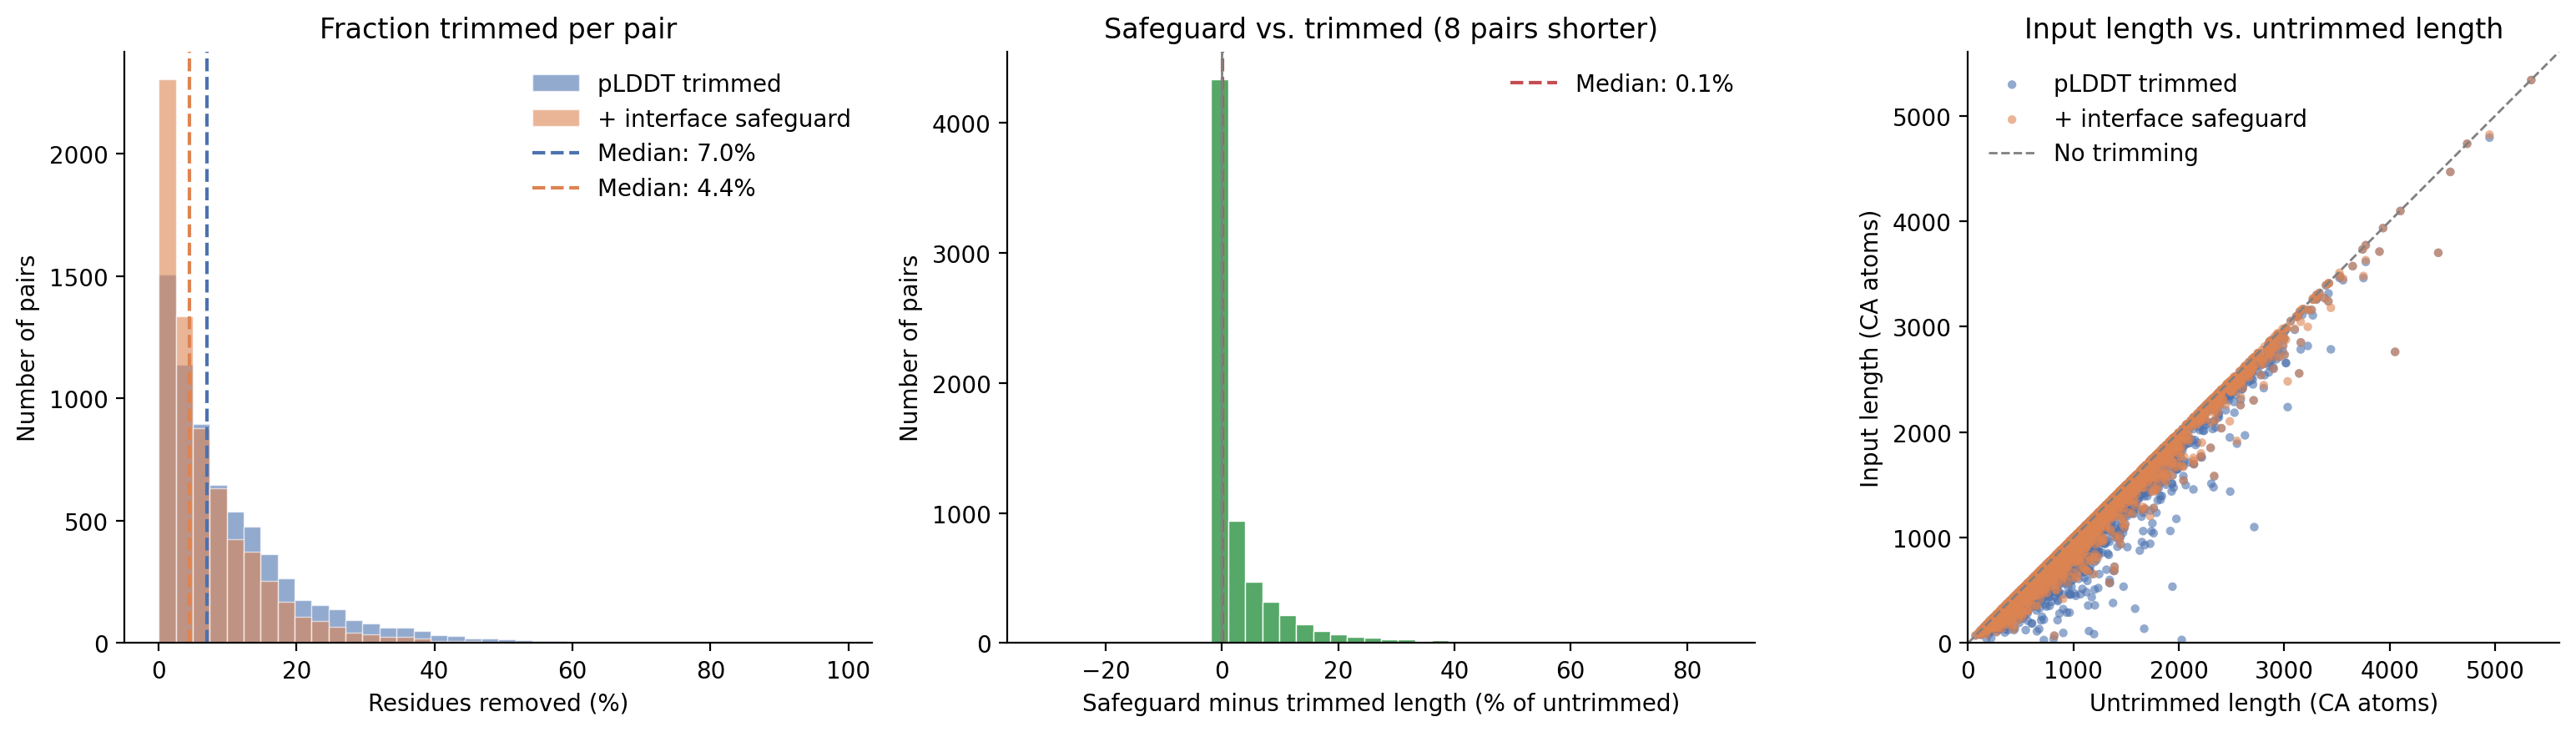

In [15]:
col_tr, col_sg = "#4C72B0", "#DD8452"

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Left: fraction removed, trimmed vs safeguard
ax = axes[0]
bins = np.linspace(0, max(rel_tr.max(), rel_sg.max()), 41)
ax.hist(rel_tr, bins=bins, color=col_tr, alpha=0.6, edgecolor="white", linewidth=0.5, label="pLDDT trimmed")
ax.hist(rel_sg, bins=bins, color=col_sg, alpha=0.6, edgecolor="white", linewidth=0.5, label="+ interface safeguard")
ax.axvline(np.median(rel_tr), color=col_tr, linestyle="--", linewidth=1.5, label=f"Median: {np.median(rel_tr):.1f}%")
ax.axvline(np.median(rel_sg), color=col_sg, linestyle="--", linewidth=1.5, label=f"Median: {np.median(rel_sg):.1f}%")
ax.set_xlabel("Residues removed (%)")
ax.set_ylabel("Number of pairs")
ax.set_title("Fraction trimmed per pair")
ax.legend(frameon=False)

# Middle: change in length from trimmed -> safeguard (negative = safeguard shorter)
ax = axes[1]
ax.hist(added, bins=40, color="#55A868", edgecolor="white", linewidth=0.5)
ax.axvline(np.median(added), color="#C44E52", linestyle="--", linewidth=1.5,
           label=f"Median: {np.median(added):.1f}%")
ax.axvline(0, color="grey", linewidth=1)
ax.set_xlabel("Safeguard minus trimmed length (% of untrimmed)")
ax.set_ylabel("Number of pairs")
ax.set_title(f"Safeguard vs. trimmed ({n_shorter} pairs shorter)")
ax.legend(frameon=False)

# Right: input length vs untrimmed length
ax = axes[2]
ax.scatter(untr, tr, color=col_tr, s=14, alpha=0.6, edgecolors="none", label="pLDDT trimmed")
ax.scatter(untr, sg, color=col_sg, s=14, alpha=0.6, edgecolors="none", label="+ interface safeguard")
lim = untr.max() * 1.05
ax.plot([0, lim], [0, lim], color="grey", linestyle="--", linewidth=1, label="No trimming")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect("equal")
ax.set_xlabel("Untrimmed length (CA atoms)")
ax.set_ylabel("Input length (CA atoms)")
ax.set_title("Input length vs. untrimmed length")
ax.legend(frameon=False, loc="upper left")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

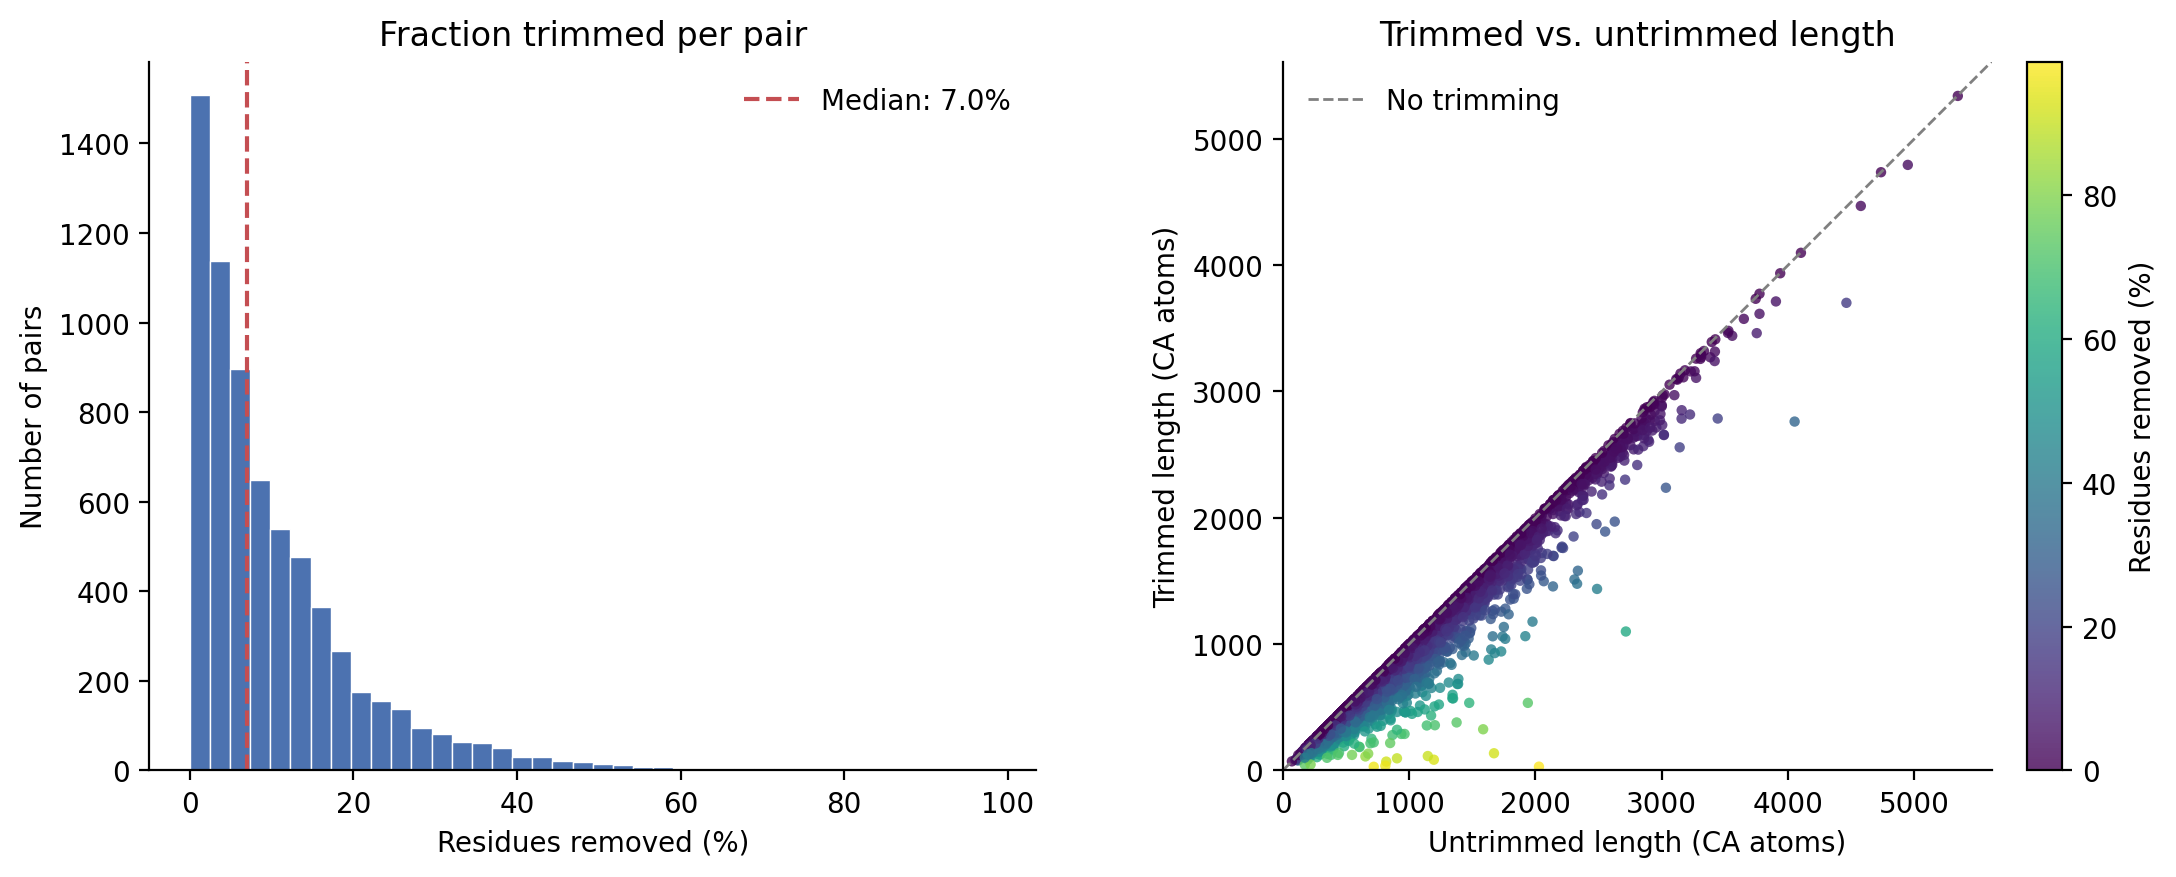

In [16]:
# %%
untr = pdb_length["length_untrimmed"].to_numpy()
tr = pdb_length["length_trimmed"].to_numpy()
rel = pdb_length["removed_trimmed"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: distribution of fraction removed
ax = axes[0]
ax.hist(rel * 100, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.5)
med = np.median(rel) * 100
ax.axvline(med, color="#C44E52", linestyle="--", linewidth=1.5,
           label=f"Median: {med:.1f}%")
ax.set_xlabel("Residues removed (%)")
ax.set_ylabel("Number of pairs")
ax.set_title("Fraction trimmed per pair")
ax.legend(frameon=False)

# Right: trimmed vs untrimmed length, coloured by fraction removed
ax = axes[1]
sc = ax.scatter(untr, tr, c=rel * 100, cmap="viridis", s=14, alpha=0.8,
                edgecolors="none")
lim = max(untr.max(), tr.max()) * 1.05
ax.plot([0, lim], [0, lim], color="grey", linestyle="--", linewidth=1,
        label="No trimming")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect("equal")
ax.set_xlabel("Untrimmed length (CA atoms)")
ax.set_ylabel("Trimmed length (CA atoms)")
ax.set_title("Trimmed vs. untrimmed length")
ax.legend(frameon=False, loc="upper left")
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Residues removed (%)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

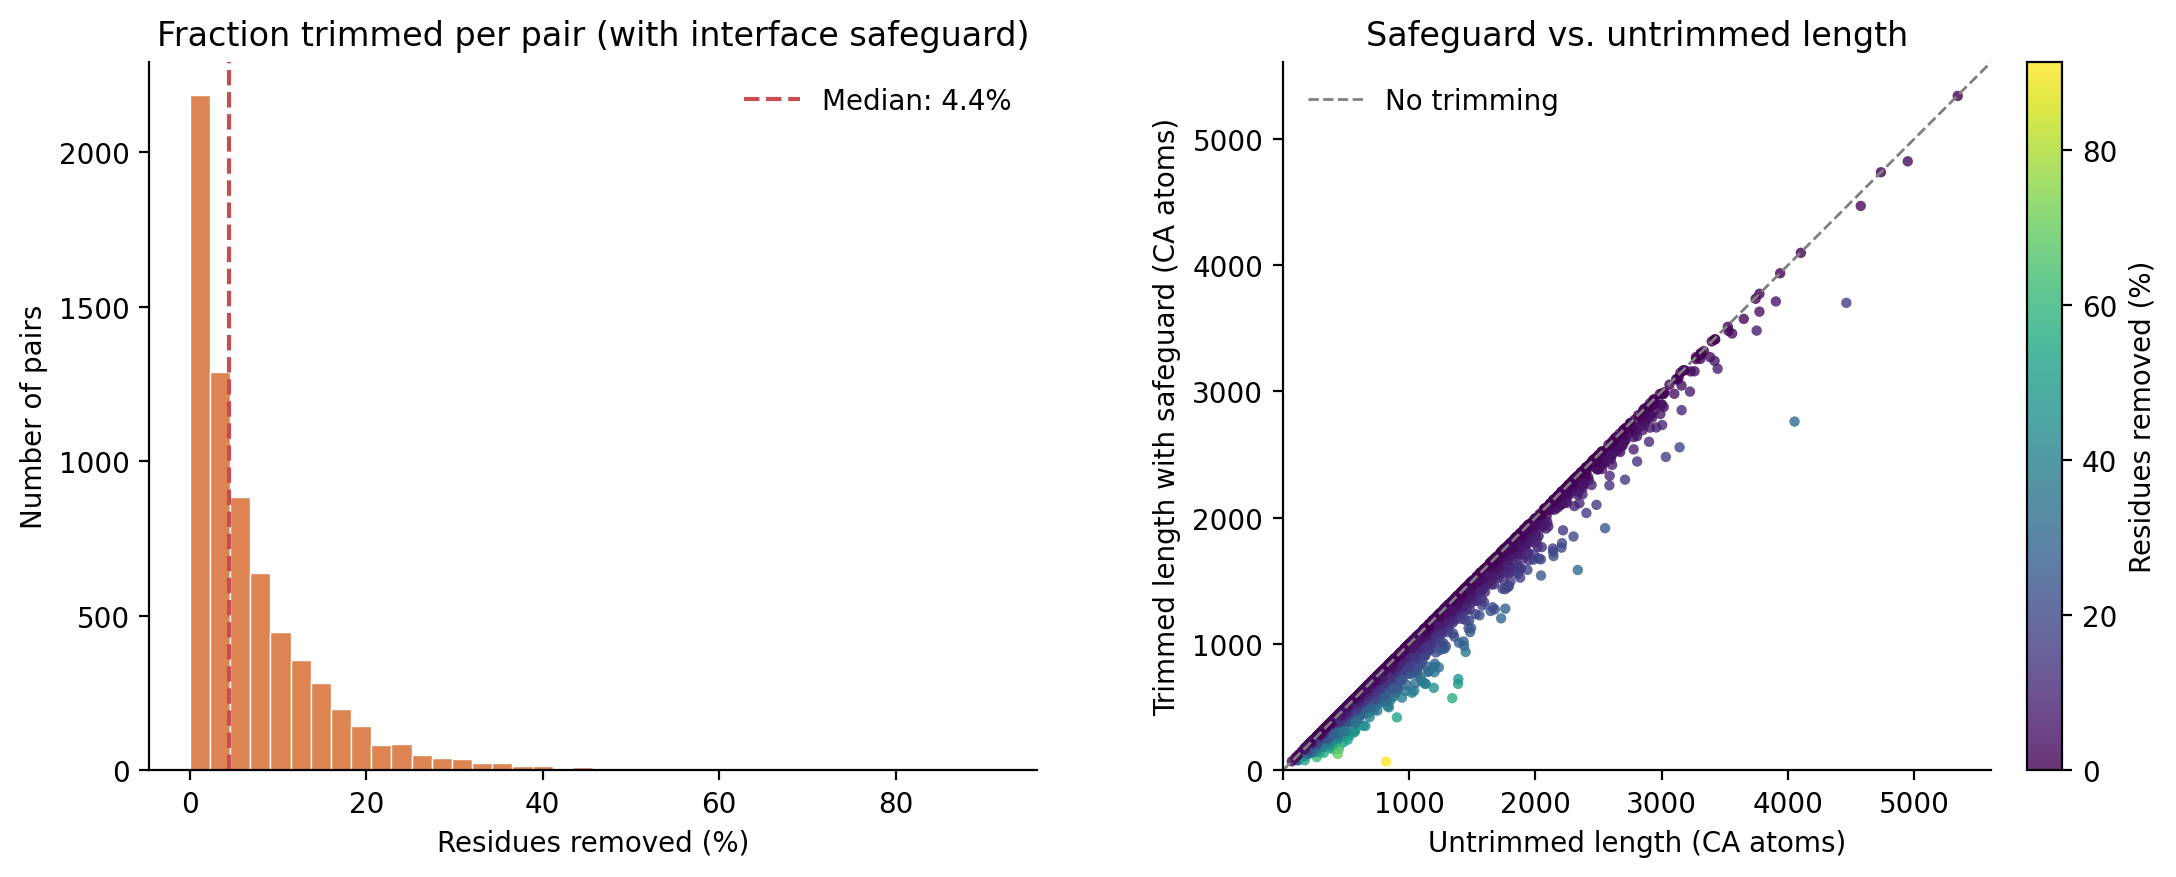

In [17]:
# %%
untr = pdb_length["length_untrimmed"].to_numpy()
sg = pdb_length["length_safeguard"].to_numpy()
rel_sg = pdb_length["removed_safeguard"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: distribution of fraction removed
ax = axes[0]
ax.hist(rel_sg * 100, bins=40, color="#DD8452", edgecolor="white", linewidth=0.5)
med = np.median(rel_sg) * 100
ax.axvline(med, color="#C44E52", linestyle="--", linewidth=1.5,
           label=f"Median: {med:.1f}%")
ax.set_xlabel("Residues removed (%)")
ax.set_ylabel("Number of pairs")
ax.set_title("Fraction trimmed per pair (with interface safeguard)")
ax.legend(frameon=False)

# Right: safeguard vs untrimmed length, coloured by fraction removed
ax = axes[1]
sc = ax.scatter(untr, sg, c=rel_sg * 100, cmap="viridis", s=14, alpha=0.8,
                edgecolors="none")
lim = max(untr.max(), sg.max()) * 1.05
ax.plot([0, lim], [0, lim], color="grey", linestyle="--", linewidth=1,
        label="No trimming")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect("equal")
ax.set_xlabel("Untrimmed length (CA atoms)")
ax.set_ylabel("Trimmed length with safeguard (CA atoms)")
ax.set_title("Safeguard vs. untrimmed length")
ax.legend(frameon=False, loc="upper left")
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Residues removed (%)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

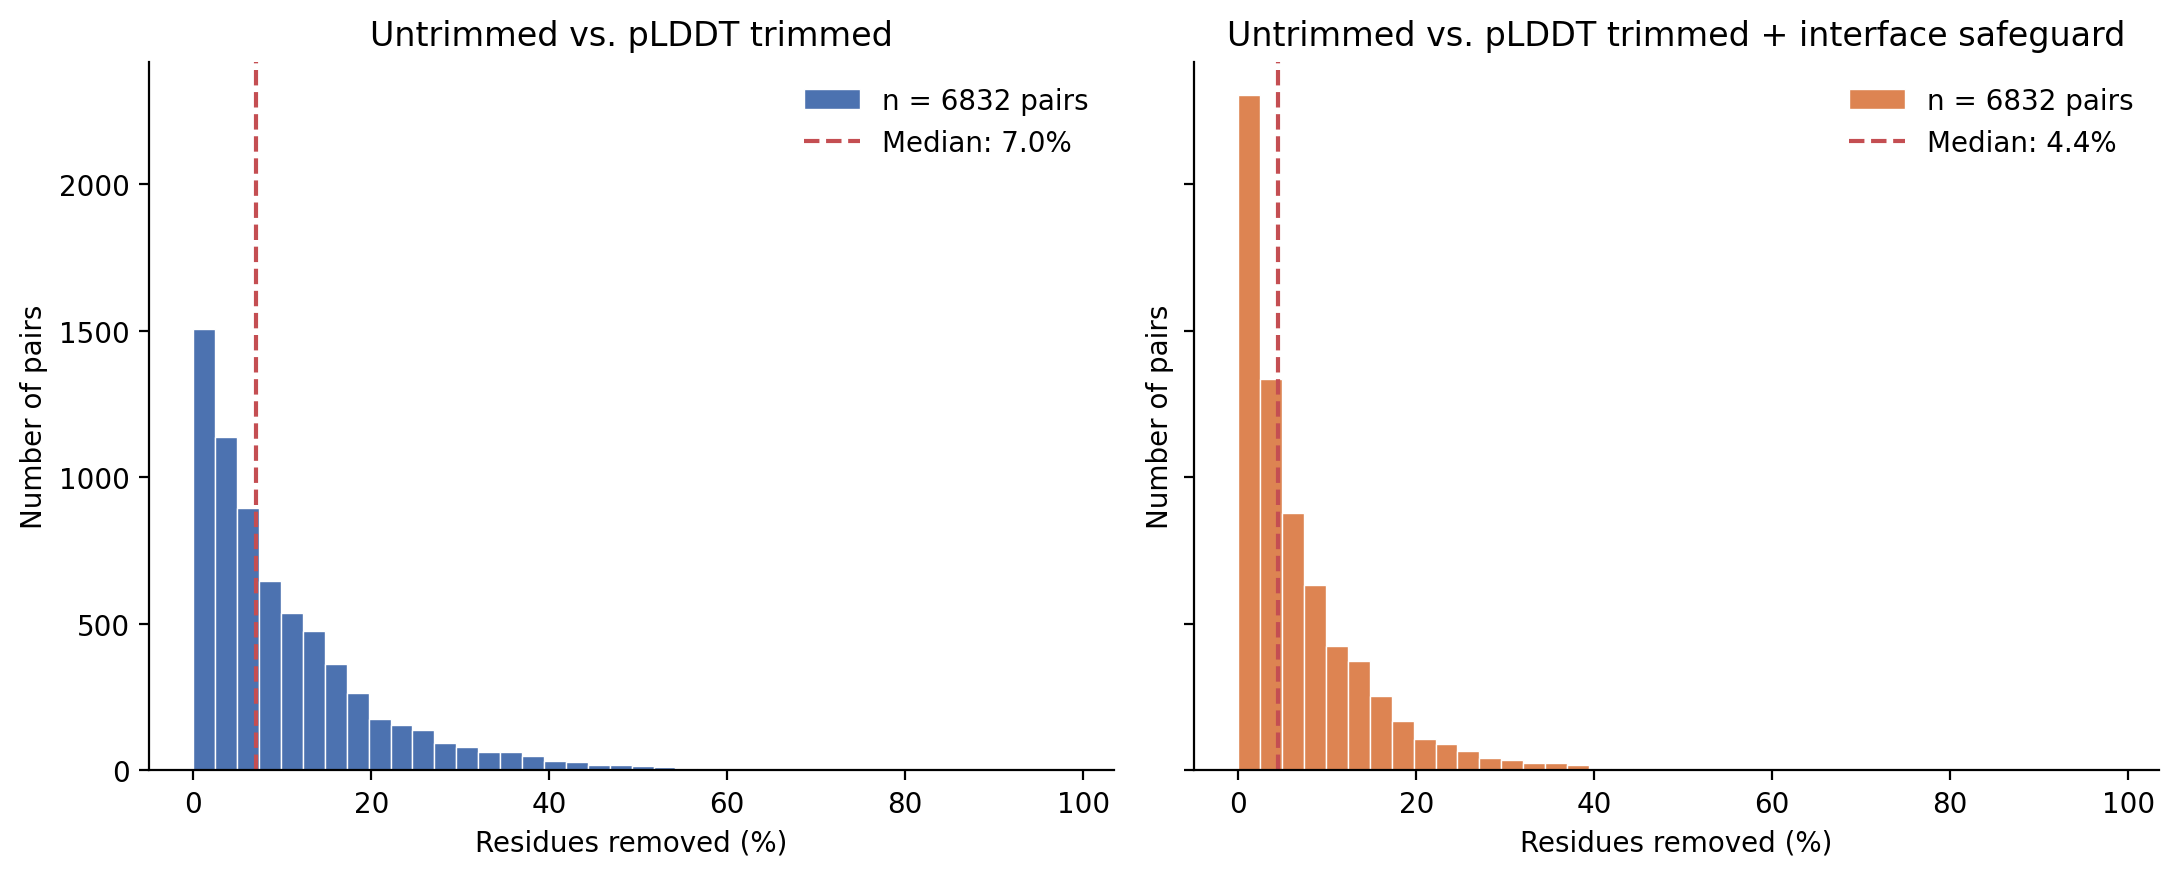

In [18]:
# %%
rel_tr = pdb_length["removed_trimmed"].to_numpy() * 100
rel_sg = pdb_length["removed_safeguard"].to_numpy() * 100

groups = [
    (rel_tr, "pLDDT trimmed", "#4C72B0"),
    (rel_sg, "pLDDT trimmed + interface safeguard", "#DD8452"),
]

bins = np.linspace(0, max(rel_tr.max(), rel_sg.max()), 41)  # same bins for both panels

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

for ax, (vals, name, color) in zip(axes, groups):
    ax.hist(vals, bins=bins, color=color, edgecolor="white", linewidth=0.5,
            label=f"n = {len(vals)} pairs")
    med = np.median(vals)
    ax.axvline(med, color="#C44E52", linestyle="--", linewidth=1.5,
               label=f"Median: {med:.1f}%")
    ax.set_xlabel("Residues removed (%)")
    ax.set_ylabel("Number of pairs")
    ax.set_title(f"Untrimmed vs. {name}")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

is there a diff between homo- and heterodimer

In [19]:
parts = pl.col("pair").str.split("_")

pdb_length = pdb_length.with_columns(
    pl.when(parts.list.get(0) == parts.list.get(1))
    .then(pl.lit("homo"))
    .otherwise(pl.lit("hetero"))
    .alias("pair_type")
)

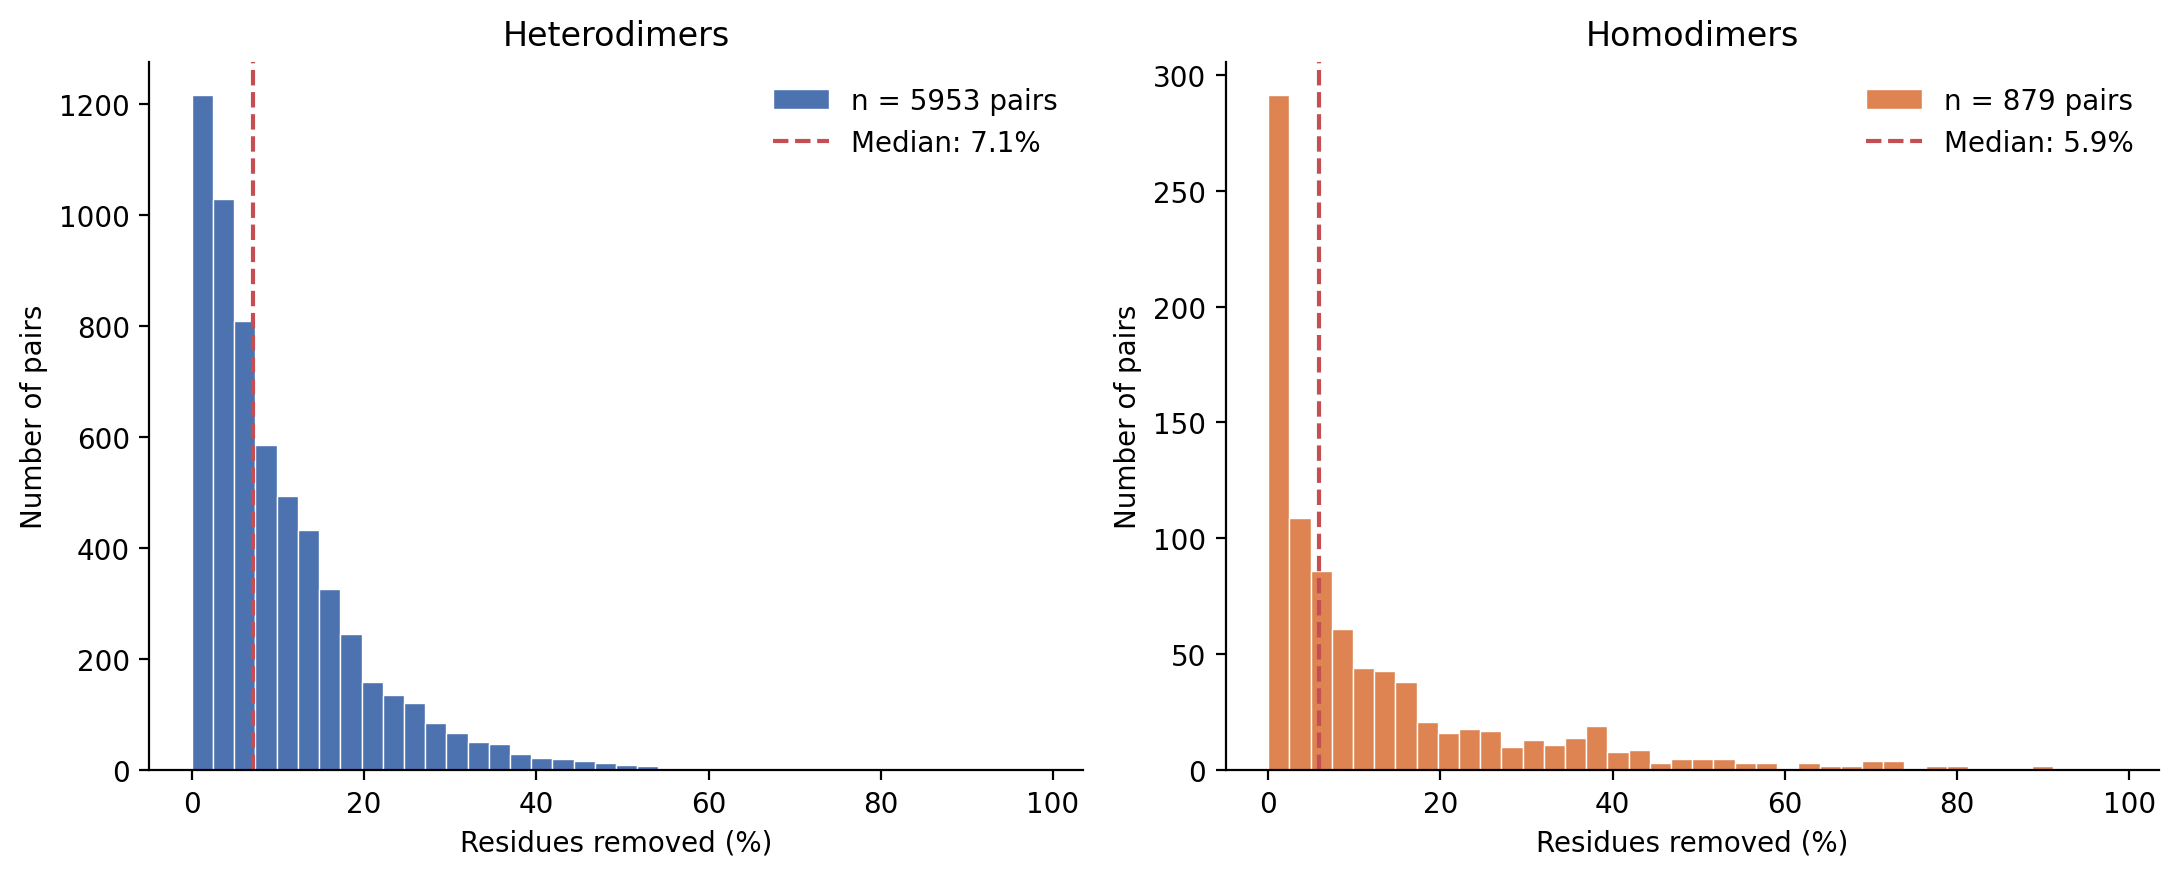

In [20]:
pair_type = pdb_length["pair_type"].to_numpy()

groups = [
    ("hetero", "Heterodimers", "#4C72B0"),
    ("homo", "Homodimers", "#DD8452"),
]

bins = np.linspace(0, rel.max() * 100, 41)  # same bins for both panels

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)

for ax, (key, name, color) in zip(axes, groups):
    vals = rel[pair_type == key] * 100
    assert len(vals) > 0, f"no pairs with pair_type == {key!r}"

    ax.hist(vals, bins=bins, color=color, edgecolor="white", linewidth=0.5,
            label=f"n = {len(vals)} pairs")
    med = np.median(vals)
    ax.axvline(med, color="#C44E52", linestyle="--", linewidth=1.5,
               label=f"Median: {med:.1f}%")

    ax.set_xlabel("Residues removed (%)")
    ax.set_ylabel("Number of pairs")
    ax.set_title(name)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

would a dfferent cutoff be ebetter? that 8 A

(6832, 14)
simulation reproduces folder 19 (0 A) and folder 20 (8 A) for all pairs
shape: (6, 5)
┌─────────────┬──────────────────┬────────────────┬────────────────────────┬───────────────────────┐
│ keep_dist_A ┆ median_removed_% ┆ mean_removed_% ┆ pairs_with_nothing_rem ┆ pairs_with_none_kept_ │
│ ---         ┆ ---              ┆ ---            ┆ oved                   ┆ chain                 │
│ i64         ┆ f64              ┆ f64            ┆ ---                    ┆ ---                   │
│             ┆                  ┆                ┆ i64                    ┆ i64                   │
╞═════════════╪══════════════════╪════════════════╪════════════════════════╪═══════════════════════╡
│ 0           ┆ 7.004907         ┆ 10.486691      ┆ 67                     ┆ 9                     │
│ 4           ┆ 6.866672         ┆ 10.262933      ┆ 75                     ┆ 7                     │
│ 6           ┆ 5.479452         ┆ 8.380019       ┆ 89                     ┆ 2                 

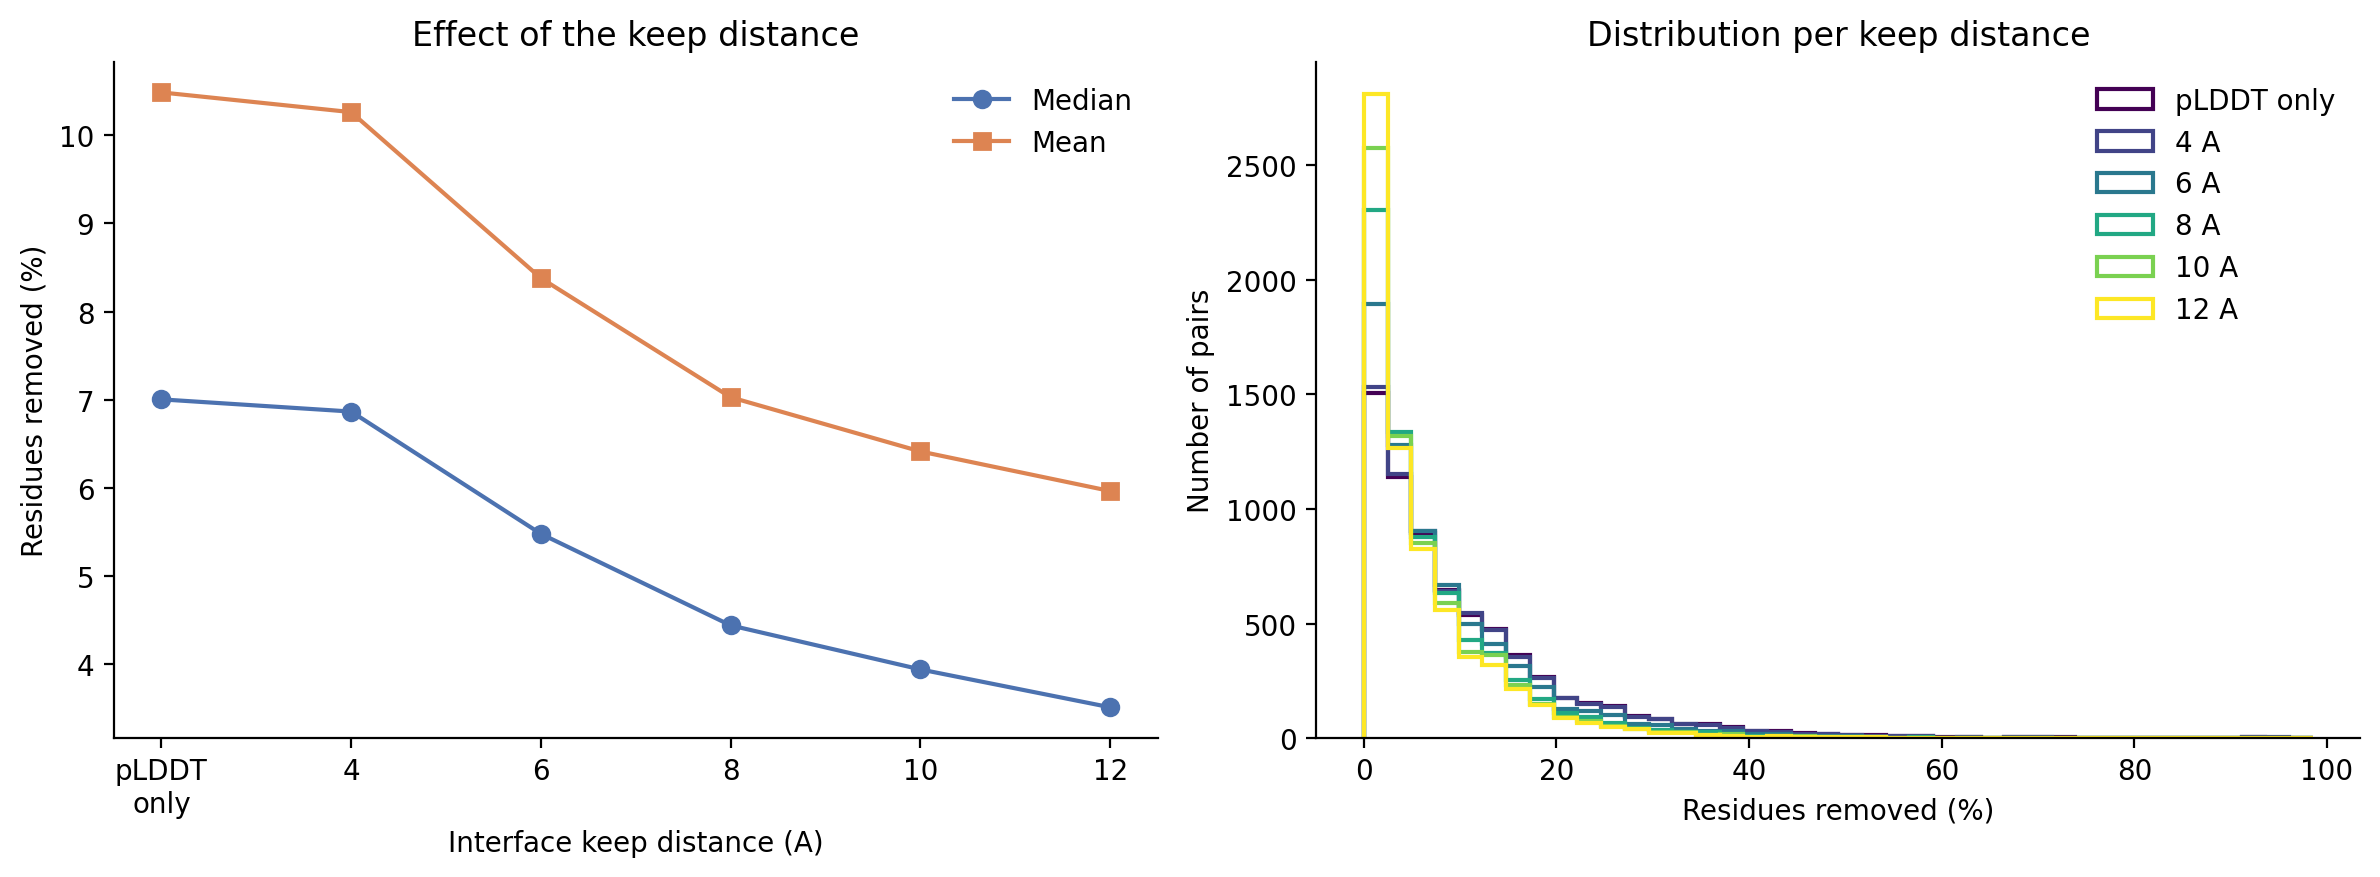

In [21]:
# %% [markdown]
# ## Sweep of the interface-keep distance (recomputed from the untrimmed pair pdbs of folder 19)

# %%
import numpy as np
from scipy.spatial import cKDTree
from concurrent.futures import ThreadPoolExecutor

PLDDT_CUTOFF = 50.0               # same as in both runs (checked in the pairs.csv logs)
DISTS = [0, 4, 6, 8, 10, 12]      # 0 = pLDDT only (folder 19), 8 = folder 20

# chain, residue number, x, y, z, b-factor (= pLDDT) of every CA atom
CA_XYZ_PATTERN = re.compile(rb"^ATOM.{8} CA [ A].{4}(.)(.{4}).{4}(.{8})(.{8})(.{8}).{6}(.{6})", re.MULTILINE)


def kept_residues(plddt, d_min, dist):
    """Same rule as trim_low_plddt_termini: keep everything between the first and last residue
    that has pLDDT >= cutoff OR a CA within `dist` A of the partner. If no residue qualifies,
    the chain stays untrimmed ('none_kept'). Returns (n_kept, none_kept)."""
    ok = plddt >= PLDDT_CUTOFF
    if dist > 0:
        ok = ok | (d_min <= dist)
    if not ok.any():
        return len(plddt), True
    idx = np.flatnonzero(ok)
    return int(idx[-1] - idx[0] + 1), False


def trim_sweep(pdb_path):
    with open(pdb_path, "rb") as f:
        matches = CA_XYZ_PATTERN.findall(f.read())
    chains = {}
    for chain, _, x, y, z, b in matches:
        chains.setdefault(chain, []).append((float(x), float(y), float(z), float(b)))
    assert len(chains) == 2, f"{pdb_path}: expected 2 chains, got {len(chains)}"

    arrs = [np.array(v) for v in chains.values()]
    xyz = [a[:, :3] for a in arrs]
    plddt = [a[:, 3] for a in arrs]
    # distance of every CA to the closest CA of the (untrimmed) partner chain
    d_min = [cKDTree(xyz[1]).query(xyz[0])[0], cKDTree(xyz[0]).query(xyz[1])[0]]

    row = {"n_total": len(arrs[0]) + len(arrs[1])}
    for dist in DISTS:
        res = [kept_residues(plddt[i], d_min[i], dist) for i in range(2)]
        row[f"kept_{dist}"] = res[0][0] + res[1][0]
        row[f"none_{dist}"] = int(res[0][1]) + int(res[1][1])  # chains left untrimmed because nothing qualified
    return row


# %%
pair_paths = {p: pairs_untrimmed[p] for p in pdb_length["pair"]}

# threads like before; switch to ProcessPoolExecutor if this turns out to be CPU bound
with ThreadPoolExecutor(max_workers=64) as ex:
    results = list(ex.map(trim_sweep, pair_paths.values()))

sweep = pl.DataFrame(results).with_columns(pair=pl.Series(list(pair_paths)))
print(sweep.shape)

# %%
# validation: the simulation must reproduce the real runs
chk = pdb_length.select("pair", "length_untrimmed", "length_trimmed", "length_safeguard").join(sweep, on="pair")
assert chk.height == pdb_length.height, "pairs lost in the join"

n_bad_untr = (chk["n_total"] != chk["length_untrimmed"]).sum()
n_bad_0 = (chk["kept_0"] != chk["length_trimmed"]).sum()
n_bad_8 = (chk["kept_8"] != chk["length_safeguard"]).sum()
assert n_bad_untr == 0, f"{n_bad_untr} pairs: untrimmed length differs from pdb_length"
assert n_bad_0 == 0, f"{n_bad_0} pairs: simulated 0 A != real folder 19 length"
assert n_bad_8 == 0, f"{n_bad_8} pairs: simulated 8 A != real folder 20 length"
print("simulation reproduces folder 19 (0 A) and folder 20 (8 A) for all pairs")

# %%
# removed fraction (%) per cutoff
sweep = sweep.with_columns(
    [(100 * (1 - pl.col(f"kept_{d}") / pl.col("n_total"))).alias(f"removed_{d}") for d in DISTS]
)

summary = pl.DataFrame({
    "keep_dist_A": DISTS,
    "median_removed_%": [sweep[f"removed_{d}"].median() for d in DISTS],
    "mean_removed_%": [sweep[f"removed_{d}"].mean() for d in DISTS],
    "pairs_with_nothing_removed": [(sweep[f"removed_{d}"] == 0).sum() for d in DISTS],
    "pairs_with_none_kept_chain": [(sweep[f"none_{d}"] > 0).sum() for d in DISTS],
})
print(summary)

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: median / mean removed vs cutoff
ax = axes[0]
x = np.arange(len(DISTS))
ax.plot(x, summary["median_removed_%"].to_numpy(), marker="o", color="#4C72B0", label="Median")
ax.plot(x, summary["mean_removed_%"].to_numpy(), marker="s", color="#DD8452", label="Mean")
ax.set_xticks(x)
ax.set_xticklabels(["pLDDT\nonly" if d == 0 else str(d) for d in DISTS])
ax.set_xlabel("Interface keep distance (A)")
ax.set_ylabel("Residues removed (%)")
ax.set_title("Effect of the keep distance")
ax.legend(frameon=False)

# Right: distribution of removed fraction per cutoff
ax = axes[1]
bins = np.linspace(0, max(sweep[f"removed_{d}"].max() for d in DISTS), 41)
cmap = plt.get_cmap("viridis")
for i, d in enumerate(DISTS):
    ax.hist(sweep[f"removed_{d}"].to_numpy(), bins=bins, histtype="step", linewidth=1.5,
            color=cmap(i / (len(DISTS) - 1)), label="pLDDT only" if d == 0 else f"{d} A")
ax.set_xlabel("Residues removed (%)")
ax.set_ylabel("Number of pairs")
ax.set_title("Distribution per keep distance")
ax.legend(frameon=False)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

Did trimming the inputs allowed for more succesful assemblies

pae: 41 complexes
pae + pLDDT trimmed: 41 complexes
pae + pLDDT trimmed + interface safeguard: 41 complexes


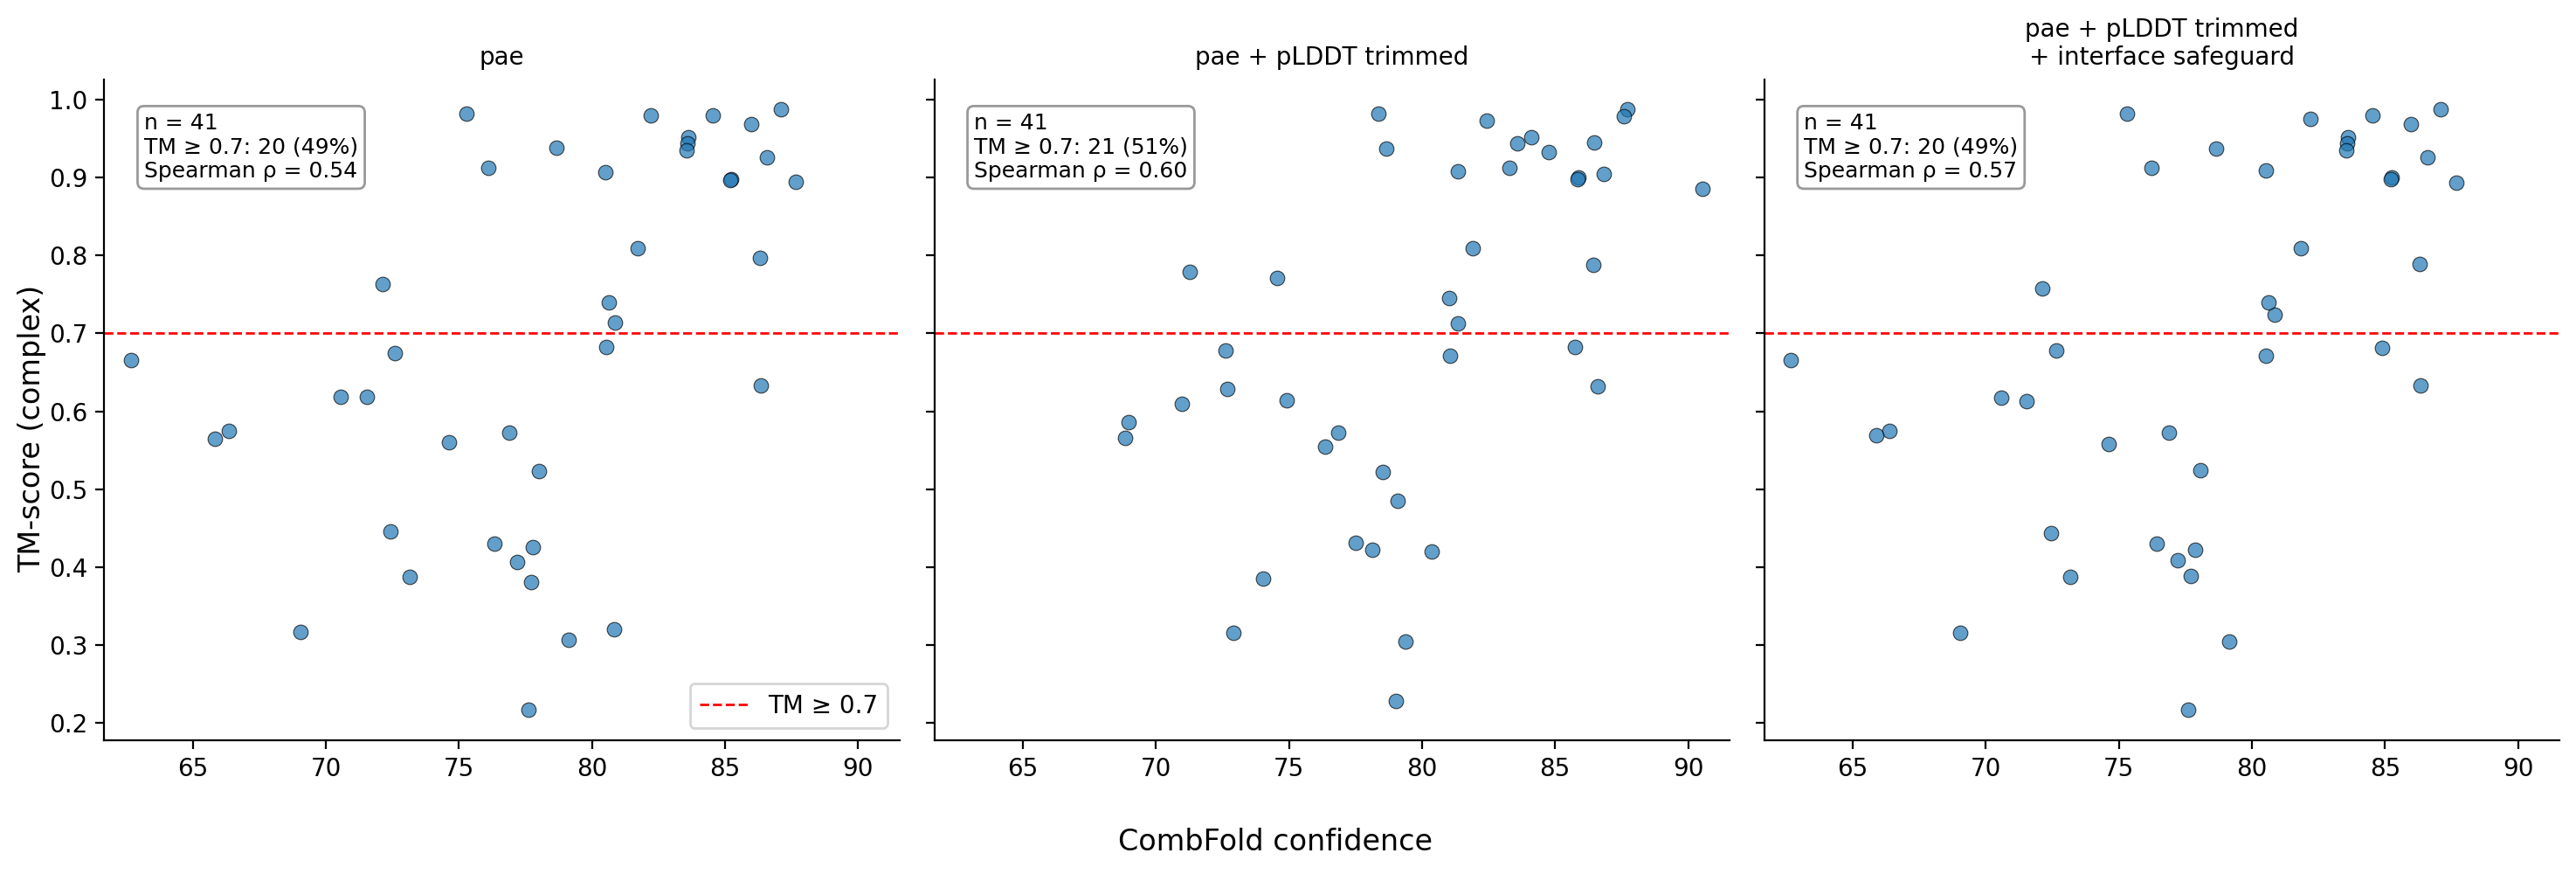

In [22]:

# Load all runs, add confidence, keep the highest-confidence output per complex

# %%
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats


def add_confidence(df: pl.DataFrame) -> pl.DataFrame:
    conf = {}
    for d in {Path(p).parent for p in df["combfold_output_path"]}:
        with open(d / "confidence.txt") as f:
            conf.update({k: float(v) for k, v in (line.split() for line in f if line.strip())})

    # replace_strict raises if a path has no confidence -> acts as an assert
    return df.with_columns(
        pl.col("combfold_output_path")
        .replace_strict(conf, return_dtype=pl.Float64)
        .alias("CF_confidence")
    )


def load(folder: str) -> pl.DataFrame:
    df = add_confidence(
        pl.read_parquet(data_dir / "Pipeline" / folder / "cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")
    )
    # highest confidence output per complex, then only complexes with > 2 proteins
    return (
        df.sort("CF_confidence", descending=True)
        .group_by("complex_ac", maintain_order=True)
        .first()
        .filter(pl.col("n_proteins") > 2)
    )


# %% [markdown]
# ## Load the three runs

# %%
variants = {
    "pae": "18_CP_model_based_on_pae",
    "pae + pLDDT trimmed": "19_CP_pae_plddt_trimmed",
    "pae + pLDDT trimmed\n+ interface safeguard": "20_CP_pae_plddt_trimmed_interface_safeguard",
}

metrics_all = {name: load(folder) for name, folder in variants.items()}
for name, df in metrics_all.items():
    assert df["complex_ac"].is_unique().all(), f"{name}: more than one row per complex"
    print(f"{name.replace(chr(10), ' ')}: {df.height} complexes")

# %% [markdown]
# ## TM-score vs. confidence

# %%
all_conf = np.concatenate([df["CF_confidence"].to_numpy() for df in metrics_all.values()])
xlim = (all_conf.min() - 1, all_conf.max() + 1)  # shared limits from the data, nothing clipped

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, (name, df) in zip(axes.flat, metrics_all.items()):
    x = df["CF_confidence"].to_numpy()
    y = df["usalign_cpx_tm_score"].to_numpy()
    spearman_r, _ = stats.spearmanr(x, y)
    n_high = (y >= 0.7).sum()

    ax.scatter(x, y, alpha=0.7, edgecolors="k", linewidths=0.4)
    ax.axhline(0.7, color="red", linestyle="--", linewidth=1, label="TM ≥ 0.7")
    ax.set_title(name, fontsize=10)
    ax.set_xlim(*xlim)
    ax.annotate(
        f"n = {len(x)}\n"
        f"TM ≥ 0.7: {n_high} ({n_high / len(x):.0%})\n"
        f"Spearman ρ = {spearman_r:.2f}",
        xy=(0.05, 0.95), xycoords="axes fraction", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8),
    )
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend(loc="lower right")
fig.supxlabel("CombFold confidence")
fig.supylabel("TM-score (complex)")
fig.tight_layout()
plt.show()

# %% [markdown]
# ## Confidence: untrimmed vs trimmed (paired per complex)

# %%
name_untr, name_tr, name_sg = list(metrics_all.keys())

41 complexes in all three runs
{'comparison': 'untrimmed vs. trimmed', 'n': 41, 'tr higher': 38, 'tr lower': 3, 'identical': 0, 'median change': 0.6488999999999976, 'mean change': 1.5613878048780485, 'wilcoxon p': 1.2732925824820995e-11, 'spearman rho': 0.9559233449477353}
{'comparison': 'untrimmed vs. safeguard', 'n': 41, 'sg higher': 24, 'sg lower': 15, 'identical': 2, 'median change': 0.004199999999997317, 'mean change': 0.11469024390243818, 'wilcoxon p': 0.026973983576667252, 'spearman rho': 0.9949477351916378}
{'comparison': 'trimmed vs. safeguard', 'n': 41, 'sg higher': 2, 'sg lower': 37, 'identical': 2, 'median change': -0.6428999999999974, 'mean change': -1.4466975609756103, 'wilcoxon p': 6.642422688126822e-08, 'spearman rho': 0.9590592334494775}


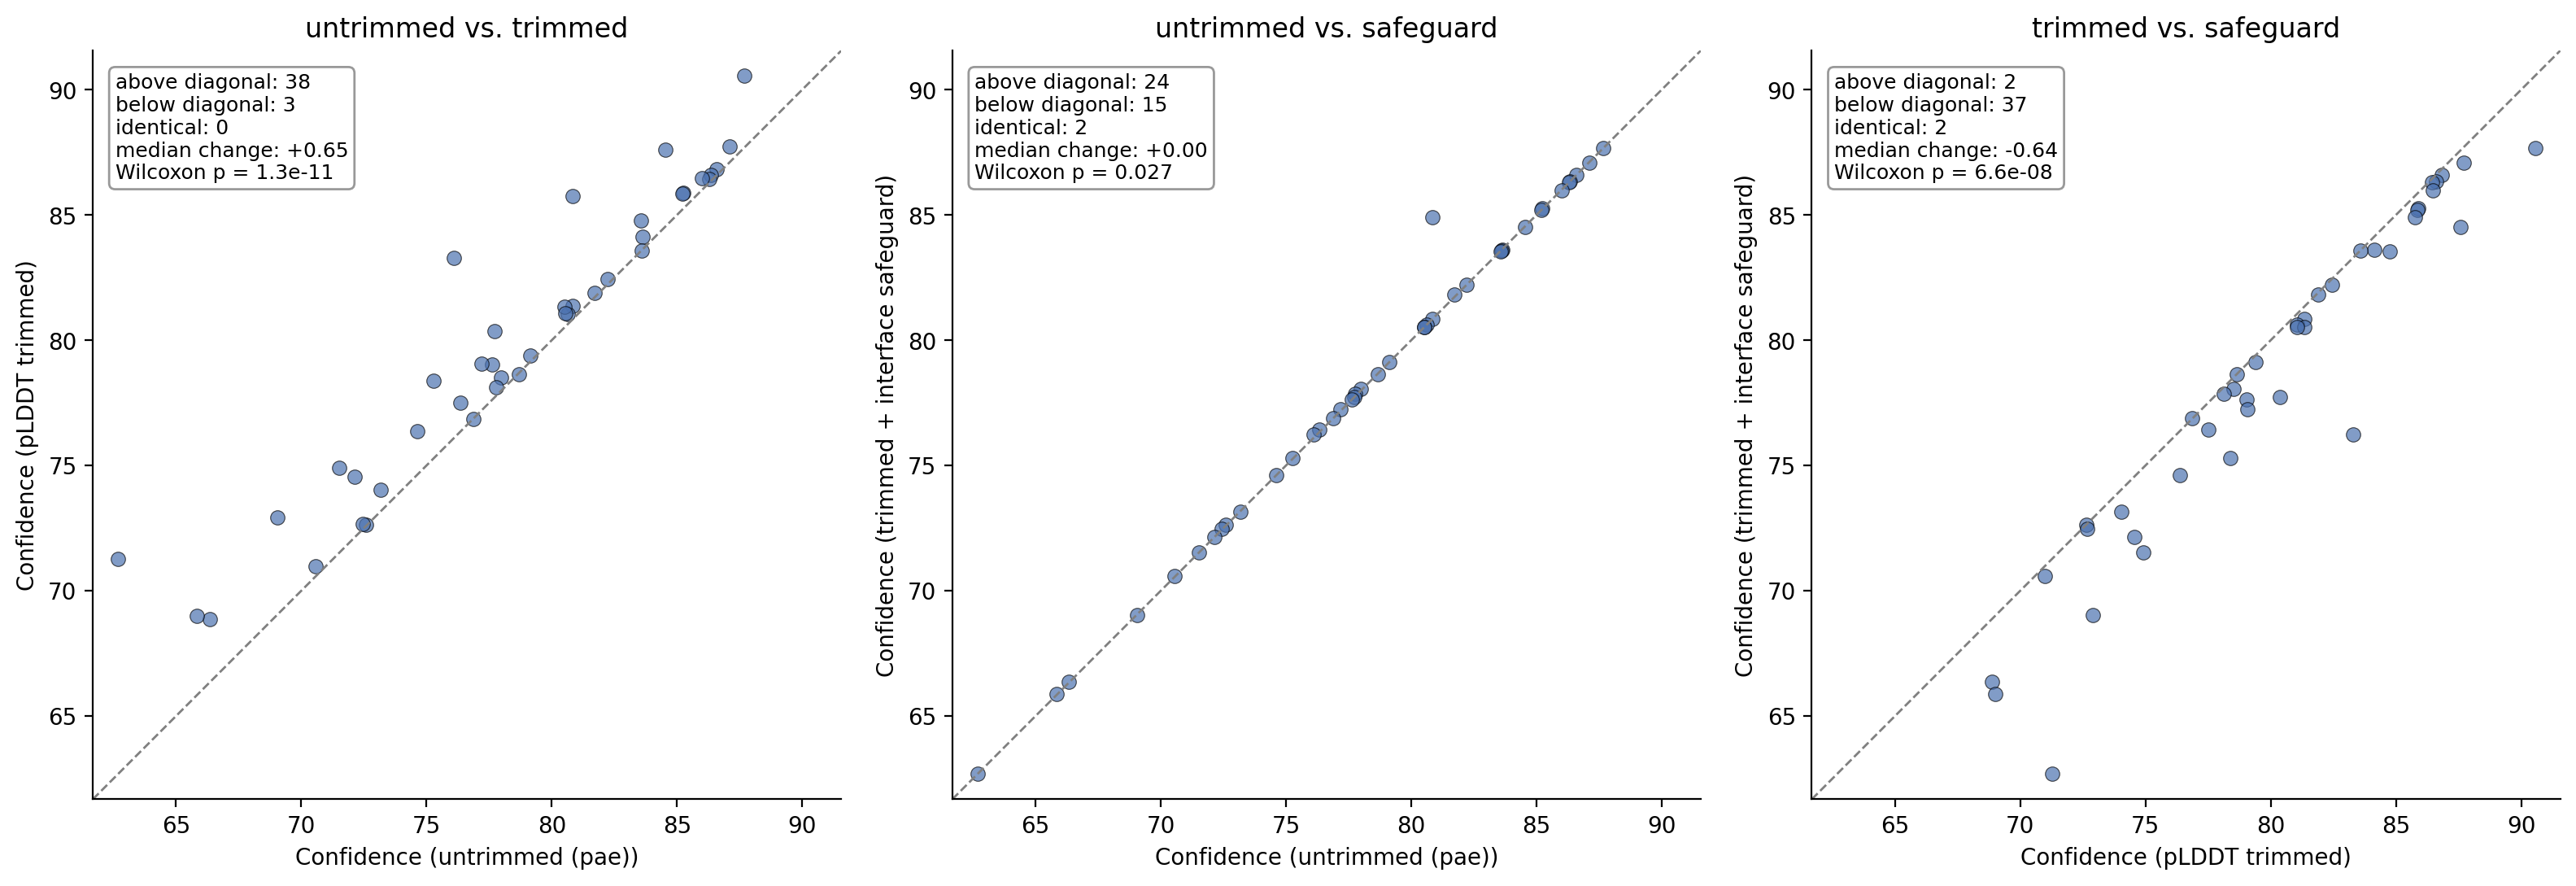

In [23]:
# %% [markdown]
# ## Confidence: pairwise comparison of the three runs (paired per complex)

# %%
name_untr, name_tr, name_sg = list(metrics_all.keys())
short = {name_untr: "untr", name_tr: "tr", name_sg: "sg"}

paired = None
for name, tag in short.items():
    df = metrics_all[name].select("complex_ac", pl.col("CF_confidence").alias(f"conf_{tag}"))
    paired = df if paired is None else paired.join(df, on="complex_ac", how="inner")

# the joins must not lose any complex
for name in short:
    assert paired.height == metrics_all[name].height, f"complex sets differ: {name} has {metrics_all[name].height}, paired {paired.height}"
print(f"{paired.height} complexes in all three runs")

# %%
comparisons = [
    ("untrimmed vs. trimmed", "untr", "tr"),
    ("untrimmed vs. safeguard", "untr", "sg"),
    ("trimmed vs. safeguard", "tr", "sg"),
]

tol = 1e-9  # confidences closer than this count as identical
rows = []
for label, a, b in comparisons:
    x = paired[f"conf_{a}"].to_numpy()
    y = paired[f"conf_{b}"].to_numpy()
    d = y - x
    n_same = int((np.abs(d) <= tol).sum())
    if n_same < len(d):
        p = stats.wilcoxon(x, y, zero_method="wilcox").pvalue  # paired, drops identical pairs
    else:
        p = float("nan")  # all identical, nothing to test
    rows.append({
        "comparison": label,
        "n": len(d),
        f"{b} higher": int((d > tol).sum()),
        f"{b} lower": int((d < -tol).sum()),
        "identical": n_same,
        "median change": float(np.median(d)),
        "mean change": float(d.mean()),
        "wilcoxon p": p,
        "spearman rho": stats.spearmanr(x, y)[0],
    })
# the "higher"/"lower" columns have different names per row, so print each row on its own
for r in rows:
    print(r)

# %%
conf_all = np.concatenate([paired[f"conf_{t}"].to_numpy() for t in ["untr", "tr", "sg"]])
lo, hi = conf_all.min() - 1, conf_all.max() + 1

axis_label = {"untr": "untrimmed (pae)", "tr": "pLDDT trimmed", "sg": "trimmed + interface safeguard"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

for ax, (label, a, b), r in zip(axes, comparisons, rows):
    x = paired[f"conf_{a}"].to_numpy()
    y = paired[f"conf_{b}"].to_numpy()
    ax.scatter(x, y, s=40, color="#4C72B0", alpha=0.7, edgecolors="k", linewidths=0.4)
    ax.plot([lo, hi], [lo, hi], color="grey", linestyle="--", linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_xlabel(f"Confidence ({axis_label[a]})")
    ax.set_ylabel(f"Confidence ({axis_label[b]})")
    ax.set_title(label)
    ax.annotate(
        f"above diagonal: {r[f'{b} higher']}\n"
        f"below diagonal: {r[f'{b} lower']}\n"
        f"identical: {r['identical']}\n"
        f"median change: {r['median change']:+.2f}\n"
        f"Wilcoxon p = {r['wilcoxon p']:.2g}",
        xy=(0.03, 0.97), xycoords="axes fraction", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8),
    )
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

41 complexes in all three runs
{'comparison': 'untrimmed vs. trimmed', 'n': 41, 'tr higher': 16, 'tr lower': 20, 'identical': 5, 'tr better by > 0.02': 6, 'tr worse by > 0.02': 2, 'within ±0.02': 33, 'median change': 0.0, 'mean change': 0.017291219512195113, 'wilcoxon p': 0.8751615065669858, 'spearman rho': 0.96602787456446}
{'comparison': 'untrimmed vs. safeguard', 'n': 41, 'sg higher': 16, 'sg lower': 19, 'identical': 6, 'sg better by > 0.02': 1, 'sg worse by > 0.02': 0, 'within ±0.02': 40, 'median change': 0.0, 'mean change': 0.008514390243902433, 'wilcoxon p': 0.793270337259859, 'spearman rho': 0.9729965156794427}
{'comparison': 'trimmed vs. safeguard', 'n': 41, 'sg higher': 19, 'sg lower': 15, 'identical': 7, 'sg better by > 0.02': 2, 'sg worse by > 0.02': 4, 'within ±0.02': 35, 'median change': 0.0, 'mean change': -0.008776829268292681, 'wilcoxon p': 0.817467886098501, 'spearman rho': 0.9893728222996517}


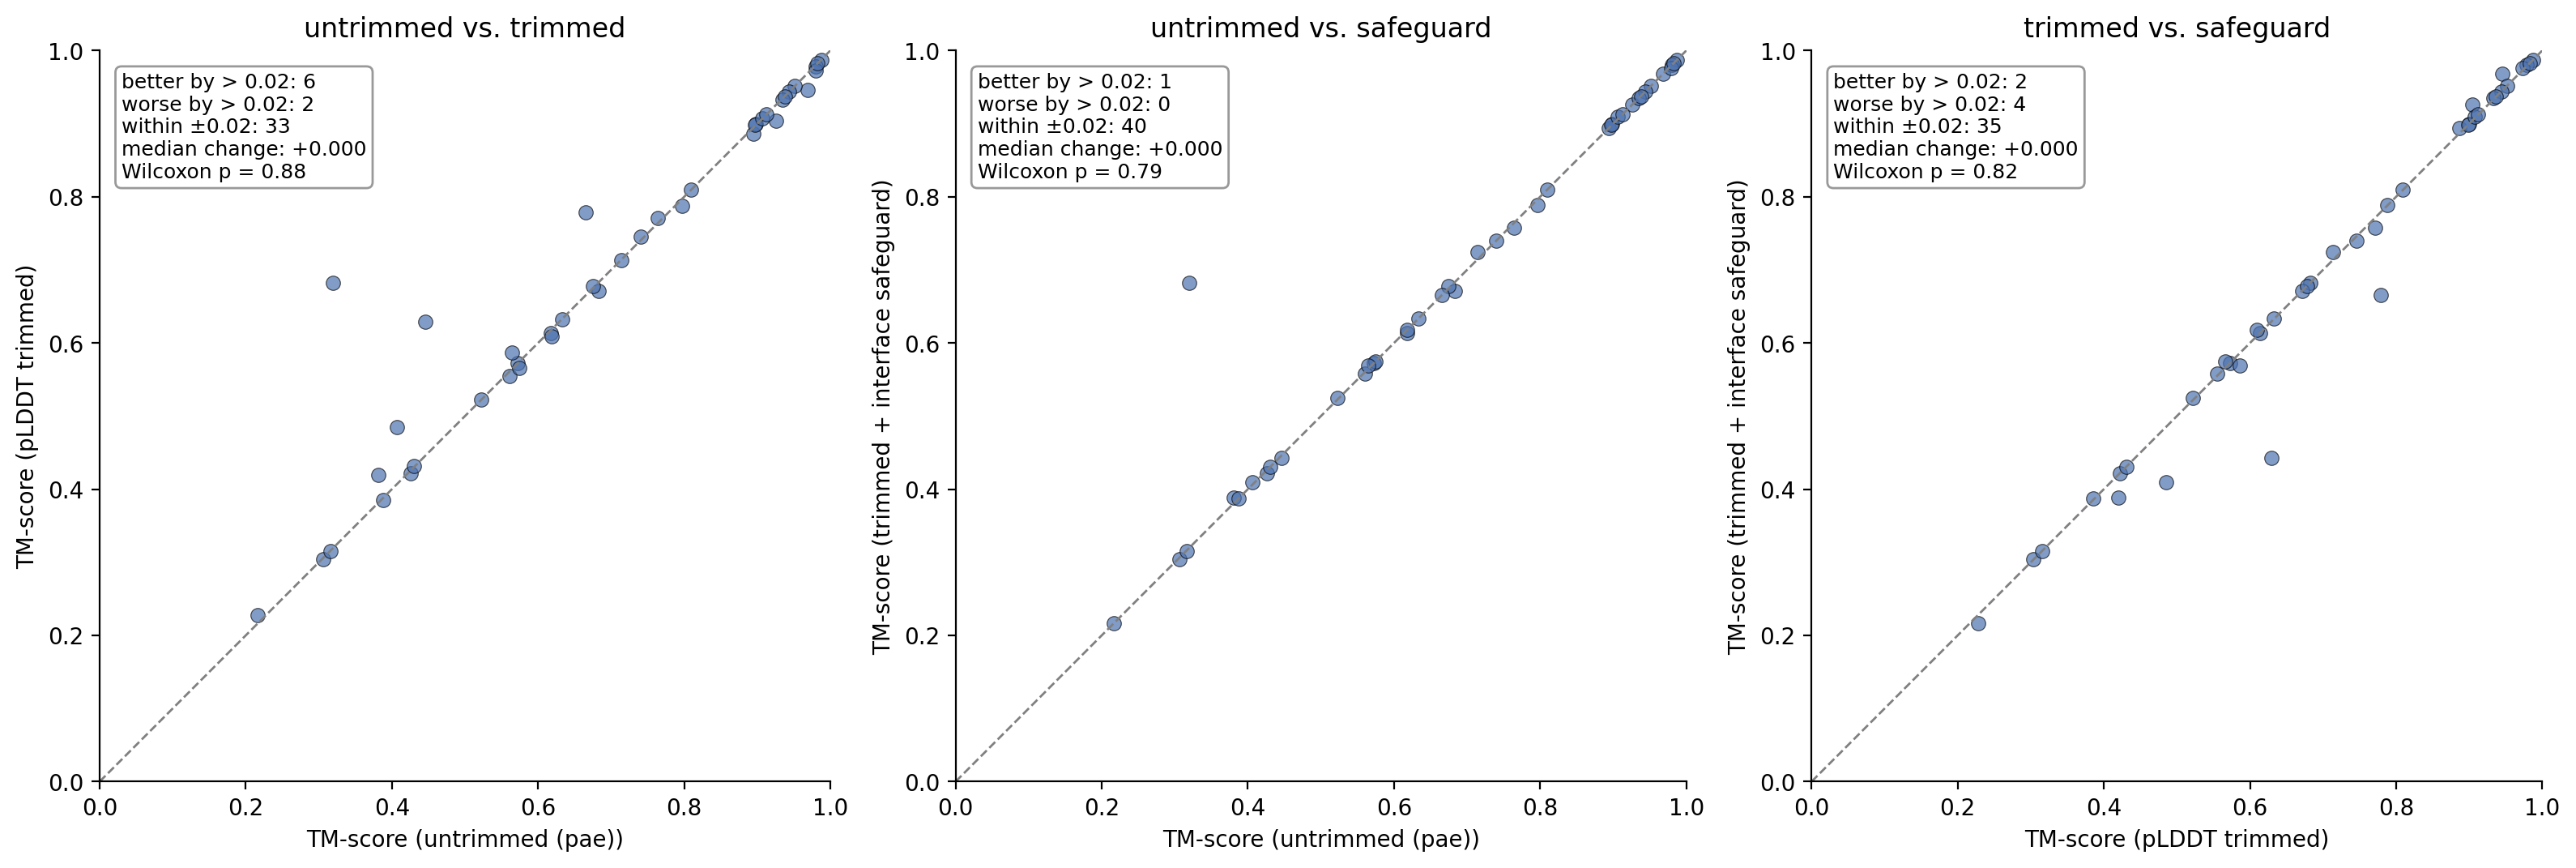

In [24]:
# %% [markdown]
# ## TM-score: pairwise comparison of the three runs (paired per complex)

# %%
paired_tm = None
for name, tag in short.items():
    df = metrics_all[name].select("complex_ac", pl.col("usalign_cpx_tm_score").alias(f"tm_{tag}"))
    paired_tm = df if paired_tm is None else paired_tm.join(df, on="complex_ac", how="inner")

# the joins must not lose any complex
for name in short:
    assert paired_tm.height == metrics_all[name].height, f"complex sets differ: {name} has {metrics_all[name].height}, paired {paired_tm.height}"
assert paired_tm["tm_untr"].null_count() + paired_tm["tm_tr"].null_count() + paired_tm["tm_sg"].null_count() == 0, "null TM-scores"
print(f"{paired_tm.height} complexes in all three runs")

# %%
tol = 1e-9     # TM-scores closer than this count as identical
thr = 0.02     # |change| <= thr counts as "about the same" (same threshold as earlier)

rows_tm = []
for label, a, b in comparisons:
    x = paired_tm[f"tm_{a}"].to_numpy()
    y = paired_tm[f"tm_{b}"].to_numpy()
    d = y - x
    n_same = int((np.abs(d) <= tol).sum())
    if n_same < len(d):
        p = stats.wilcoxon(x, y, zero_method="wilcox").pvalue  # paired, drops identical pairs
    else:
        p = float("nan")  # all identical, nothing to test
    rows_tm.append({
        "comparison": label,
        "n": len(d),
        f"{b} higher": int((d > tol).sum()),
        f"{b} lower": int((d < -tol).sum()),
        "identical": n_same,
        f"{b} better by > {thr}": int((d > thr).sum()),
        f"{b} worse by > {thr}": int((d < -thr).sum()),
        f"within ±{thr}": int((np.abs(d) <= thr).sum()),
        "median change": float(np.median(d)),
        "mean change": float(d.mean()),
        "wilcoxon p": p,
        "spearman rho": stats.spearmanr(x, y)[0],
    })
for r in rows_tm:
    print(r)

# %%
axis_label = {"untr": "untrimmed (pae)", "tr": "pLDDT trimmed", "sg": "trimmed + interface safeguard"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

for ax, (label, a, b), r in zip(axes, comparisons, rows_tm):
    x = paired_tm[f"tm_{a}"].to_numpy()
    y = paired_tm[f"tm_{b}"].to_numpy()
    ax.scatter(x, y, s=40, color="#4C72B0", alpha=0.7, edgecolors="k", linewidths=0.4)
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_xlabel(f"TM-score ({axis_label[a]})")
    ax.set_ylabel(f"TM-score ({axis_label[b]})")
    ax.set_title(label)
    ax.annotate(
        f"better by > {thr}: {r[f'{b} better by > {thr}']}\n"
        f"worse by > {thr}: {r[f'{b} worse by > {thr}']}\n"
        f"within ±{thr}: {r[f'within ±{thr}']}\n"
        f"median change: {r['median change']:+.3f}\n"
        f"Wilcoxon p = {r['wilcoxon p']:.2g}",
        xy=(0.03, 0.97), xycoords="axes fraction", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8),
    )
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

## Performance on complexes with unknown strcuture

In [25]:
import ast, json, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

N_PROTEINS_ABOVE = 2    # keep complexes with MORE than this many proteins
CONF_THRESHOLD = 80

RUNS = {   # run name -> pipeline folder
    "ranking": "10_all_CP_complexes",           # reference: pair models chosen by AF ranking score
    "pae": "18_CP_model_based_on_pae",
    "trimmed": "19_CP_pae_plddt_trimmed",
    "safeguard": "20_CP_pae_plddt_trimmed_interface_safeguard",    # trimmed + interface safeguard
}
COMPARISONS = [
    ("ranking", "pae"), ("ranking", "trimmed"), ("ranking", "safeguard"),
    ("pae", "trimmed"), ("pae", "safeguard"), ("trimmed", "safeguard"),
]
RUN_COLORS = {"ranking": "#999999", "pae": "#0072B2", "trimmed": "#009E73", "safeguard": "#E69F00"}
CLASS_LABELS = {"no_sufficient_match": "No sufficient match", "no_homology_match": "No homology match"}

In [26]:
# complexes without a structure match
pdb_mapping = pl.read_csv(data_dir / "complete_complex_pdb_mapping_v2/all_pdb_matches_with_match_class.csv")
complexes_without_structure = (
    pdb_mapping
    .filter(pl.col("match_class").is_in(["no_homology_match", "no_sufficient_match"]))
    .filter(pl.col("n_proteins") > N_PROTEINS_ABOVE)
    .select("complex_ac", "match_class")
    .unique()
)
assert complexes_without_structure["complex_ac"].is_unique().all(), "a complex has more than one match_class"
print(f"{complexes_without_structure.height} complexes without a structure match")

207 complexes without a structure match


In [27]:
# read the CSVs and get the best confidence
def read_combfold_results(run_name):
    """combfold results of one run, only for the complexes without a structure match"""
    folder = RUNS[run_name]
    path = data_dir / "Pipeline" / folder / f"all_pdb_present_{folder}_pool_pipeline_complexes_combfold_results.csv"
    assert path.exists(), f"missing results file: {path}"
    results = pl.read_csv(path).join(complexes_without_structure, on="complex_ac", how="inner")
    assert results["complex_ac"].is_unique().all(), f"{path.name}: more than one row per complex"
    return results


def best_conf(col: str) -> pl.Expr:
    """'{0: 65.5, 1: 68.0}' -> 68.0 (best assembly); '{}' -> null"""
    return (pl.col(col).str.extract_all(r": [\d.]+")
            .list.eval(pl.element().str.slice(2).cast(pl.Float64)).list.max())


def best_confidence_per_complex(run_name: str) -> pl.DataFrame:
    """Highest confidence over all assemblies of pred_1/2/3 and the true stoichiometry (null = no output)."""
    conf_cols = ["CF_1_confidence", "CF_2_confidence", "CF_3_confidence", "CF_true_confidence"]
    return read_combfold_results(run_name).select(
        "complex_ac",
        pl.max_horizontal(*[best_conf(col) for col in conf_cols]).alias(run_name),
    )

In [28]:
# one row per complex, one column per run
confidence = complexes_without_structure
for run_name in RUNS:
    confidence = confidence.join(best_confidence_per_complex(run_name), on="complex_ac", how="inner")

# all runs must contain the same complexes (inner joins would silently drop the others)
for run_name in RUNS:
    assert read_combfold_results(run_name).height == confidence.height, f"{run_name}: its csv has other complexes than the other runs"
print(f"{complexes_without_structure.height} complexes in the mapping, {confidence.height} of them in all csvs")
confidence.head(3)

207 complexes in the mapping, 194 of them in all csvs


complex_ac,match_class,ranking,pae,trimmed,safeguard
str,str,f64,f64,f64,f64
"""CPX-15""","""no_sufficient_match""",68.0631,66.1652,67.1607,66.1652
"""CPX-23""","""no_sufficient_match""",78.8444,80.0614,81.0169,80.6482
"""CPX-25""","""no_sufficient_match""",82.1262,82.5538,83.0999,83.1621


In [29]:
#counts per run and match class
# how many complexes have an output / a confidence above the threshold, per run and match class
confidence_long = confidence.unpivot(index=["complex_ac", "match_class"], on=list(RUNS),
                                     variable_name="run", value_name="best_confidence")

counts_per_run_and_class = (
    confidence_long.group_by("run", "match_class", maintain_order=True)
    .agg(
        n_complexes=pl.len(),
        n_with_output=pl.col("best_confidence").is_not_null().sum(),
        n_above_threshold=(pl.col("best_confidence") > CONF_THRESHOLD).sum(),
    )
    .sort("match_class", maintain_order=True)
)
print(counts_per_run_and_class)

shape: (8, 5)
┌───────────┬─────────────────────┬─────────────┬───────────────┬───────────────────┐
│ run       ┆ match_class         ┆ n_complexes ┆ n_with_output ┆ n_above_threshold │
│ ---       ┆ ---                 ┆ ---         ┆ ---           ┆ ---               │
│ str       ┆ str                 ┆ u32         ┆ u32           ┆ u32               │
╞═══════════╪═════════════════════╪═════════════╪═══════════════╪═══════════════════╡
│ ranking   ┆ no_homology_match   ┆ 24          ┆ 23            ┆ 2                 │
│ pae       ┆ no_homology_match   ┆ 24          ┆ 23            ┆ 2                 │
│ trimmed   ┆ no_homology_match   ┆ 24          ┆ 21            ┆ 2                 │
│ safeguard ┆ no_homology_match   ┆ 24          ┆ 23            ┆ 2                 │
│ ranking   ┆ no_sufficient_match ┆ 170         ┆ 156           ┆ 19                │
│ pae       ┆ no_sufficient_match ┆ 170         ┆ 159           ┆ 19                │
│ trimmed   ┆ no_sufficient_match ┆ 170 

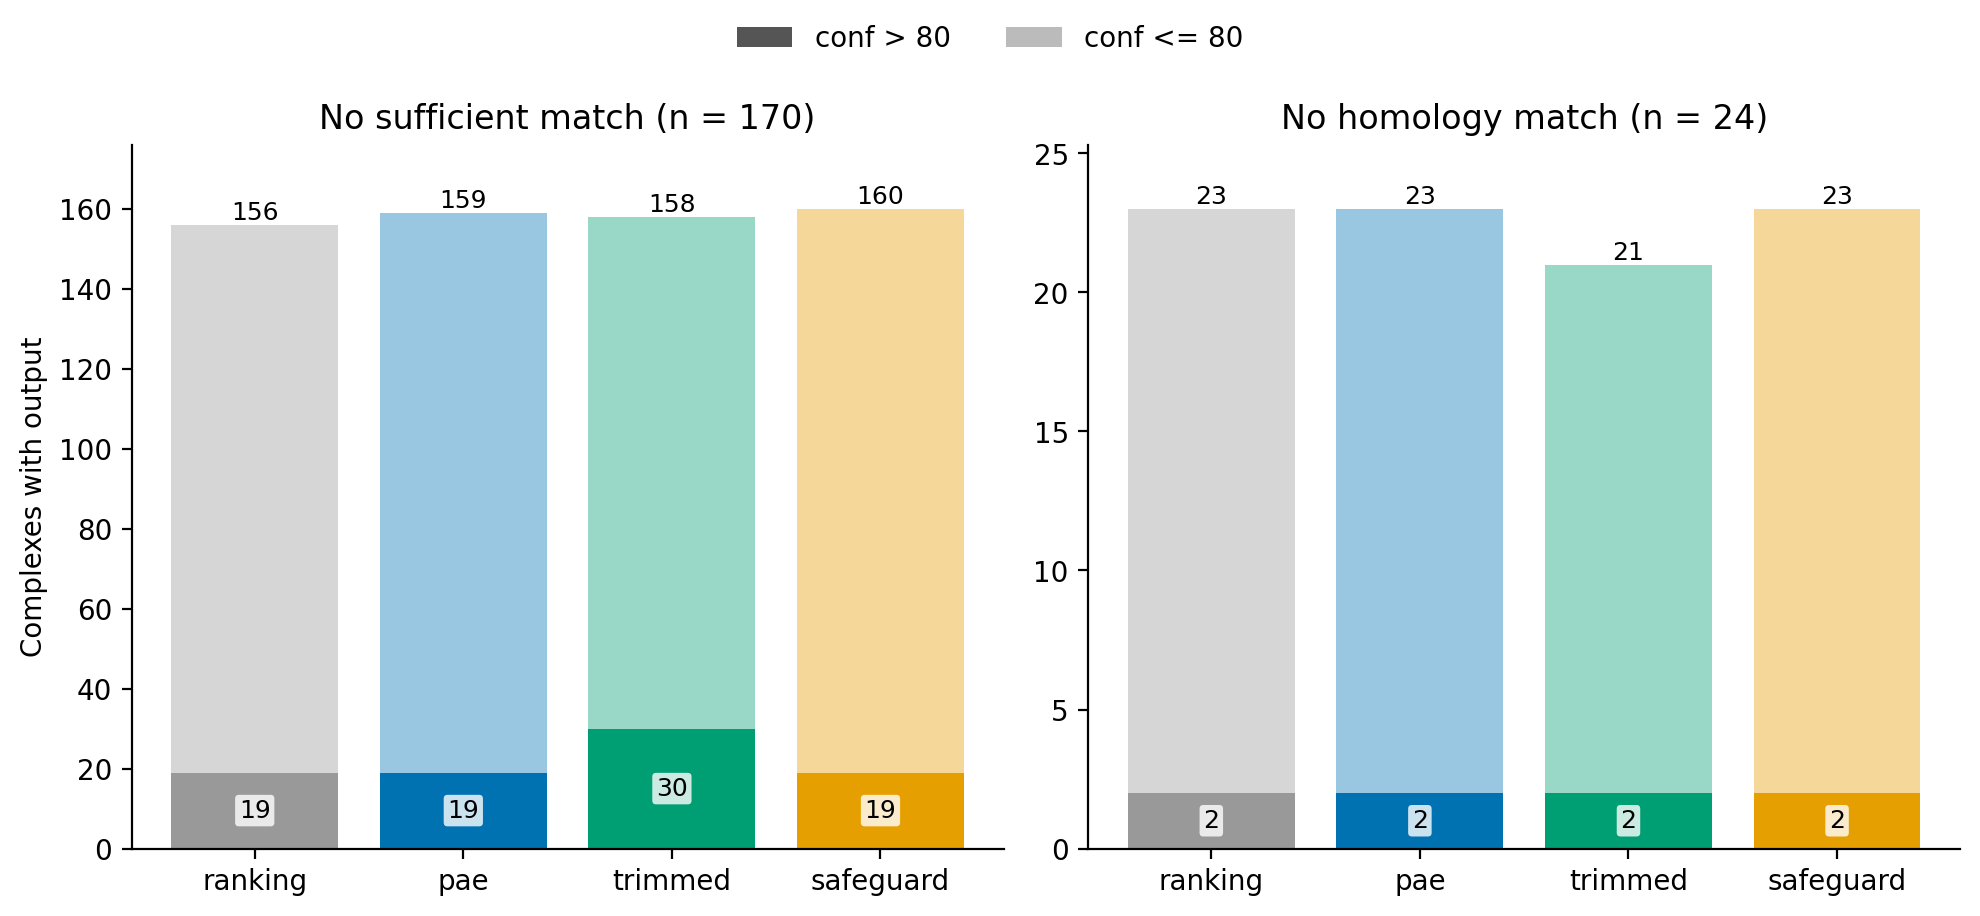


No sufficient match: 32 complexes with conf > 80 in at least one run
shape: (32, 5)
┌────────────┬─────────┬──────┬─────────┬───────────┐
│ complex_ac ┆ ranking ┆ pae  ┆ trimmed ┆ safeguard │
│ ---        ┆ ---     ┆ ---  ┆ ---     ┆ ---       │
│ str        ┆ f64     ┆ f64  ┆ f64     ┆ f64       │
╞════════════╪═════════╪══════╪═════════╪═══════════╡
│ CPX-1602   ┆ 88.1    ┆ 89.2 ┆ 89.5    ┆ 89.2      │
│ CPX-1103   ┆ 87.9    ┆ 87.8 ┆ 87.8    ┆ 87.8      │
│ CPX-3207   ┆ 82.7    ┆ 82.9 ┆ 87.7    ┆ 83.2      │
│ CPX-1192   ┆ 86.9    ┆ 87.3 ┆ 87.6    ┆ 87.3      │
│ CPX-1861   ┆ 86.2    ┆ 79.9 ┆ 80.4    ┆ 79.9      │
│ CPX-863    ┆ 77.4    ┆ 81.9 ┆ 85.0    ┆ 80.3      │
│ CPX-573    ┆ 84.7    ┆ 80.0 ┆ 80.0    ┆ 80.0      │
│ CPX-607    ┆ 83.4    ┆ 84.4 ┆ 84.6    ┆ 84.4      │
│ CPX-995    ┆ 83.2    ┆ 82.7 ┆ 84.0    ┆ 82.6      │
│ CPX-581    ┆ 82.0    ┆ 83.8 ┆ 83.9    ┆ 83.8      │
│ CPX-1053   ┆ 82.4    ┆ 83.1 ┆ 83.8    ┆ 83.1      │
│ CPX-26     ┆ 81.7    ┆ 83.5 ┆ 83.7    ┆ 82.7     

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, (match_class, class_label) in zip(axes, CLASS_LABELS.items()):
    counts = counts_per_run_and_class.filter(pl.col("match_class") == match_class)
    n_complexes = counts["n_complexes"].unique().item()    # fails if the runs disagree

    for x, run_name in enumerate(RUNS):
        row = counts.filter(pl.col("run") == run_name)
        n_above = row["n_above_threshold"].item()                  # output with conf > threshold
        n_below = row["n_with_output"].item() - n_above            # output, but conf <= threshold
        color = RUN_COLORS[run_name]

        ax.bar(x, n_above, color=color)                                  # solid: conf > threshold
        ax.bar(x, n_below, bottom=n_above, color=color, alpha=0.4)       # light:  conf <= threshold
        ax.text(x, n_above / 2, str(n_above), ha="center", va="center", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8))
        ax.text(x, n_above + n_below, str(n_above + n_below), ha="center", va="bottom", fontsize=9)

    ax.set_xticks(range(len(RUNS)))
    ax.set_xticklabels(list(RUNS))
    ax.set_title(f"{class_label} (n = {n_complexes})")
    ax.margins(y=0.1)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Complexes with output")
fig.legend(
    handles=[Patch(facecolor="#555555", label=f"conf > {CONF_THRESHOLD}"),
             Patch(facecolor="#555555", alpha=0.4, label=f"conf <= {CONF_THRESHOLD}")],
    loc="upper center", ncol=2, frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

# complexes with a confidence above the threshold in at least one run, per match class
# (the values are the best confidence per run, empty = no output)
for match_class, class_label in CLASS_LABELS.items():
    above_in_any_run = (
        confidence.filter(pl.col("match_class") == match_class)
        .filter(pl.any_horizontal(pl.col(run_name) > CONF_THRESHOLD for run_name in RUNS))
    )
    # the table must agree with the bars
    for run_name in RUNS:
        n_bar = counts_per_run_and_class.filter((pl.col("run") == run_name) & (pl.col("match_class") == match_class))["n_above_threshold"].item()
        assert above_in_any_run.filter(pl.col(run_name) > CONF_THRESHOLD).height == n_bar, f"{class_label}, {run_name}: table and bar disagree"

    print(f"\n{class_label}: {above_in_any_run.height} complexes with conf > {CONF_THRESHOLD} in at least one run")
    with pl.Config(tbl_rows=200):
        print(
            above_in_any_run
            .sort(pl.max_horizontal(*RUNS), descending=True)
            .select("complex_ac", *[pl.col(run_name).round(1) for run_name in RUNS])
        )

In [31]:
# the best complexes of the "no homology match" category, to see what comes after the two above 80
no_homology = confidence.filter(pl.col("match_class") == "no_homology_match")
print(no_homology.sort(pl.max_horizontal(*RUNS), descending=True, nulls_last=True).select("complex_ac", *RUNS).head(8))

# complexes in the mapping that are not in the csvs at all (never ran), so they cannot show up in the plot
print(complexes_without_structure.join(confidence.select("complex_ac"), on="complex_ac", how="anti"))

# the proteins of the two complexes above 80
print(read_combfold_results("pae").filter(pl.col("complex_ac").is_in(["CPX-393", "CPX-1892"])).select("complex_ac", "identifiers"))

shape: (8, 5)
┌────────────┬─────────┬─────────┬─────────┬───────────┐
│ complex_ac ┆ ranking ┆ pae     ┆ trimmed ┆ safeguard │
│ ---        ┆ ---     ┆ ---     ┆ ---     ┆ ---       │
│ str        ┆ f64     ┆ f64     ┆ f64     ┆ f64       │
╞════════════╪═════════╪═════════╪═════════╪═══════════╡
│ CPX-393    ┆ 84.4659 ┆ 85.8942 ┆ 86.0042 ┆ 85.8716   │
│ CPX-1892   ┆ 85.4932 ┆ 85.3508 ┆ 85.499  ┆ 85.3075   │
│ CPX-1832   ┆ 77.0829 ┆ 78.8635 ┆ 79.197  ┆ 78.8419   │
│ CPX-1190   ┆ 70.5099 ┆ 65.2891 ┆ 77.3092 ┆ 65.2729   │
│ CPX-1362   ┆ 64.527  ┆ 76.2568 ┆ 62.6955 ┆ 76.2356   │
│ CPX-1421   ┆ 76.1549 ┆ 75.6812 ┆ 76.2244 ┆ 75.6694   │
│ CPX-1363   ┆ 74.6089 ┆ 74.9616 ┆ 75.0068 ┆ 75.0068   │
│ CPX-3188   ┆ 59.4169 ┆ 65.982  ┆ 72.2323 ┆ 65.9973   │
└────────────┴─────────┴─────────┴─────────┴───────────┘
shape: (13, 2)
┌────────────┬─────────────────────┐
│ complex_ac ┆ match_class         │
│ ---        ┆ ---                 │
│ str        ┆ str                 │
╞════════════╪═══════════

In [32]:
#calculate gained and lost complexes
# a complex "passes" a test in a run if ...  (no output counts as not passing)
tests = {
    "has output": lambda run: pl.col(run).is_not_null(),
    f"conf > {CONF_THRESHOLD}": lambda run: (pl.col(run) > CONF_THRESHOLD).fill_null(False),
}

changes = {}   # (test, run_a, run_b) -> (gained complexes, lost complexes)
for test_name, passes in tests.items():
    for run_a, run_b in COMPARISONS:
        gained = confidence.filter(~passes(run_a) & passes(run_b)).sort(run_b, descending=True)
        lost = confidence.filter(passes(run_a) & ~passes(run_b)).sort(run_a, descending=True)
        changes[(test_name, run_a, run_b)] = (gained, lost)

In [33]:
#list the gained and lost complexes with their confidence
# the complexes: complex_ac (confidence in run A -> confidence in run B), "-" = no output
fmt = lambda value: "-" if value is None else f"{value:.1f}"

for (test_name, run_a, run_b), (gained, lost) in changes.items():
    print(f"\n{test_name} | {run_a} -> {run_b}: +{gained.height} gained, -{lost.height} lost")
    for label, table in [("gained", gained), ("lost", lost)]:
        entries = [f"{r['complex_ac']} ({fmt(r[run_a])} -> {fmt(r[run_b])})" for r in table.iter_rows(named=True)]
        if entries:
            print(f"  {label}: " + ", ".join(entries))
            


has output | ranking -> pae: +6 gained, -3 lost
  gained: CPX-1423 (- -> 75.9), CPX-1293 (- -> 74.6), CPX-1846 (- -> 69.0), CPX-1882 (- -> 68.7), CPX-1384 (- -> 68.4), CPX-1830 (- -> 56.5)
  lost: CPX-1698 (75.9 -> -), CPX-1268 (65.9 -> -), CPX-1811 (64.0 -> -)

has output | ranking -> trimmed: +6 gained, -6 lost
  gained: CPX-1423 (- -> 74.7), CPX-1846 (- -> 72.6), CPX-1882 (- -> 71.7), CPX-1384 (- -> 71.0), CPX-1387 (- -> 70.4), CPX-1830 (- -> 67.0)
  lost: CPX-5466 (72.4 -> -), CPX-3234 (72.3 -> -), CPX-1268 (65.9 -> -), CPX-1811 (64.0 -> -), CPX-36 (58.9 -> -), CPX-576 (46.7 -> -)

has output | ranking -> safeguard: +6 gained, -2 lost
  gained: CPX-1423 (- -> 75.9), CPX-1293 (- -> 74.6), CPX-1846 (- -> 68.9), CPX-1882 (- -> 68.8), CPX-1384 (- -> 68.5), CPX-1830 (- -> 55.7)
  lost: CPX-1268 (65.9 -> -), CPX-1811 (64.0 -> -)

has output | pae -> trimmed: +2 gained, -5 lost
  gained: CPX-1698 (- -> 77.0), CPX-1387 (- -> 70.4)
  lost: CPX-5466 (79.5 -> -), CPX-3234 (77.8 -> -), CPX-12

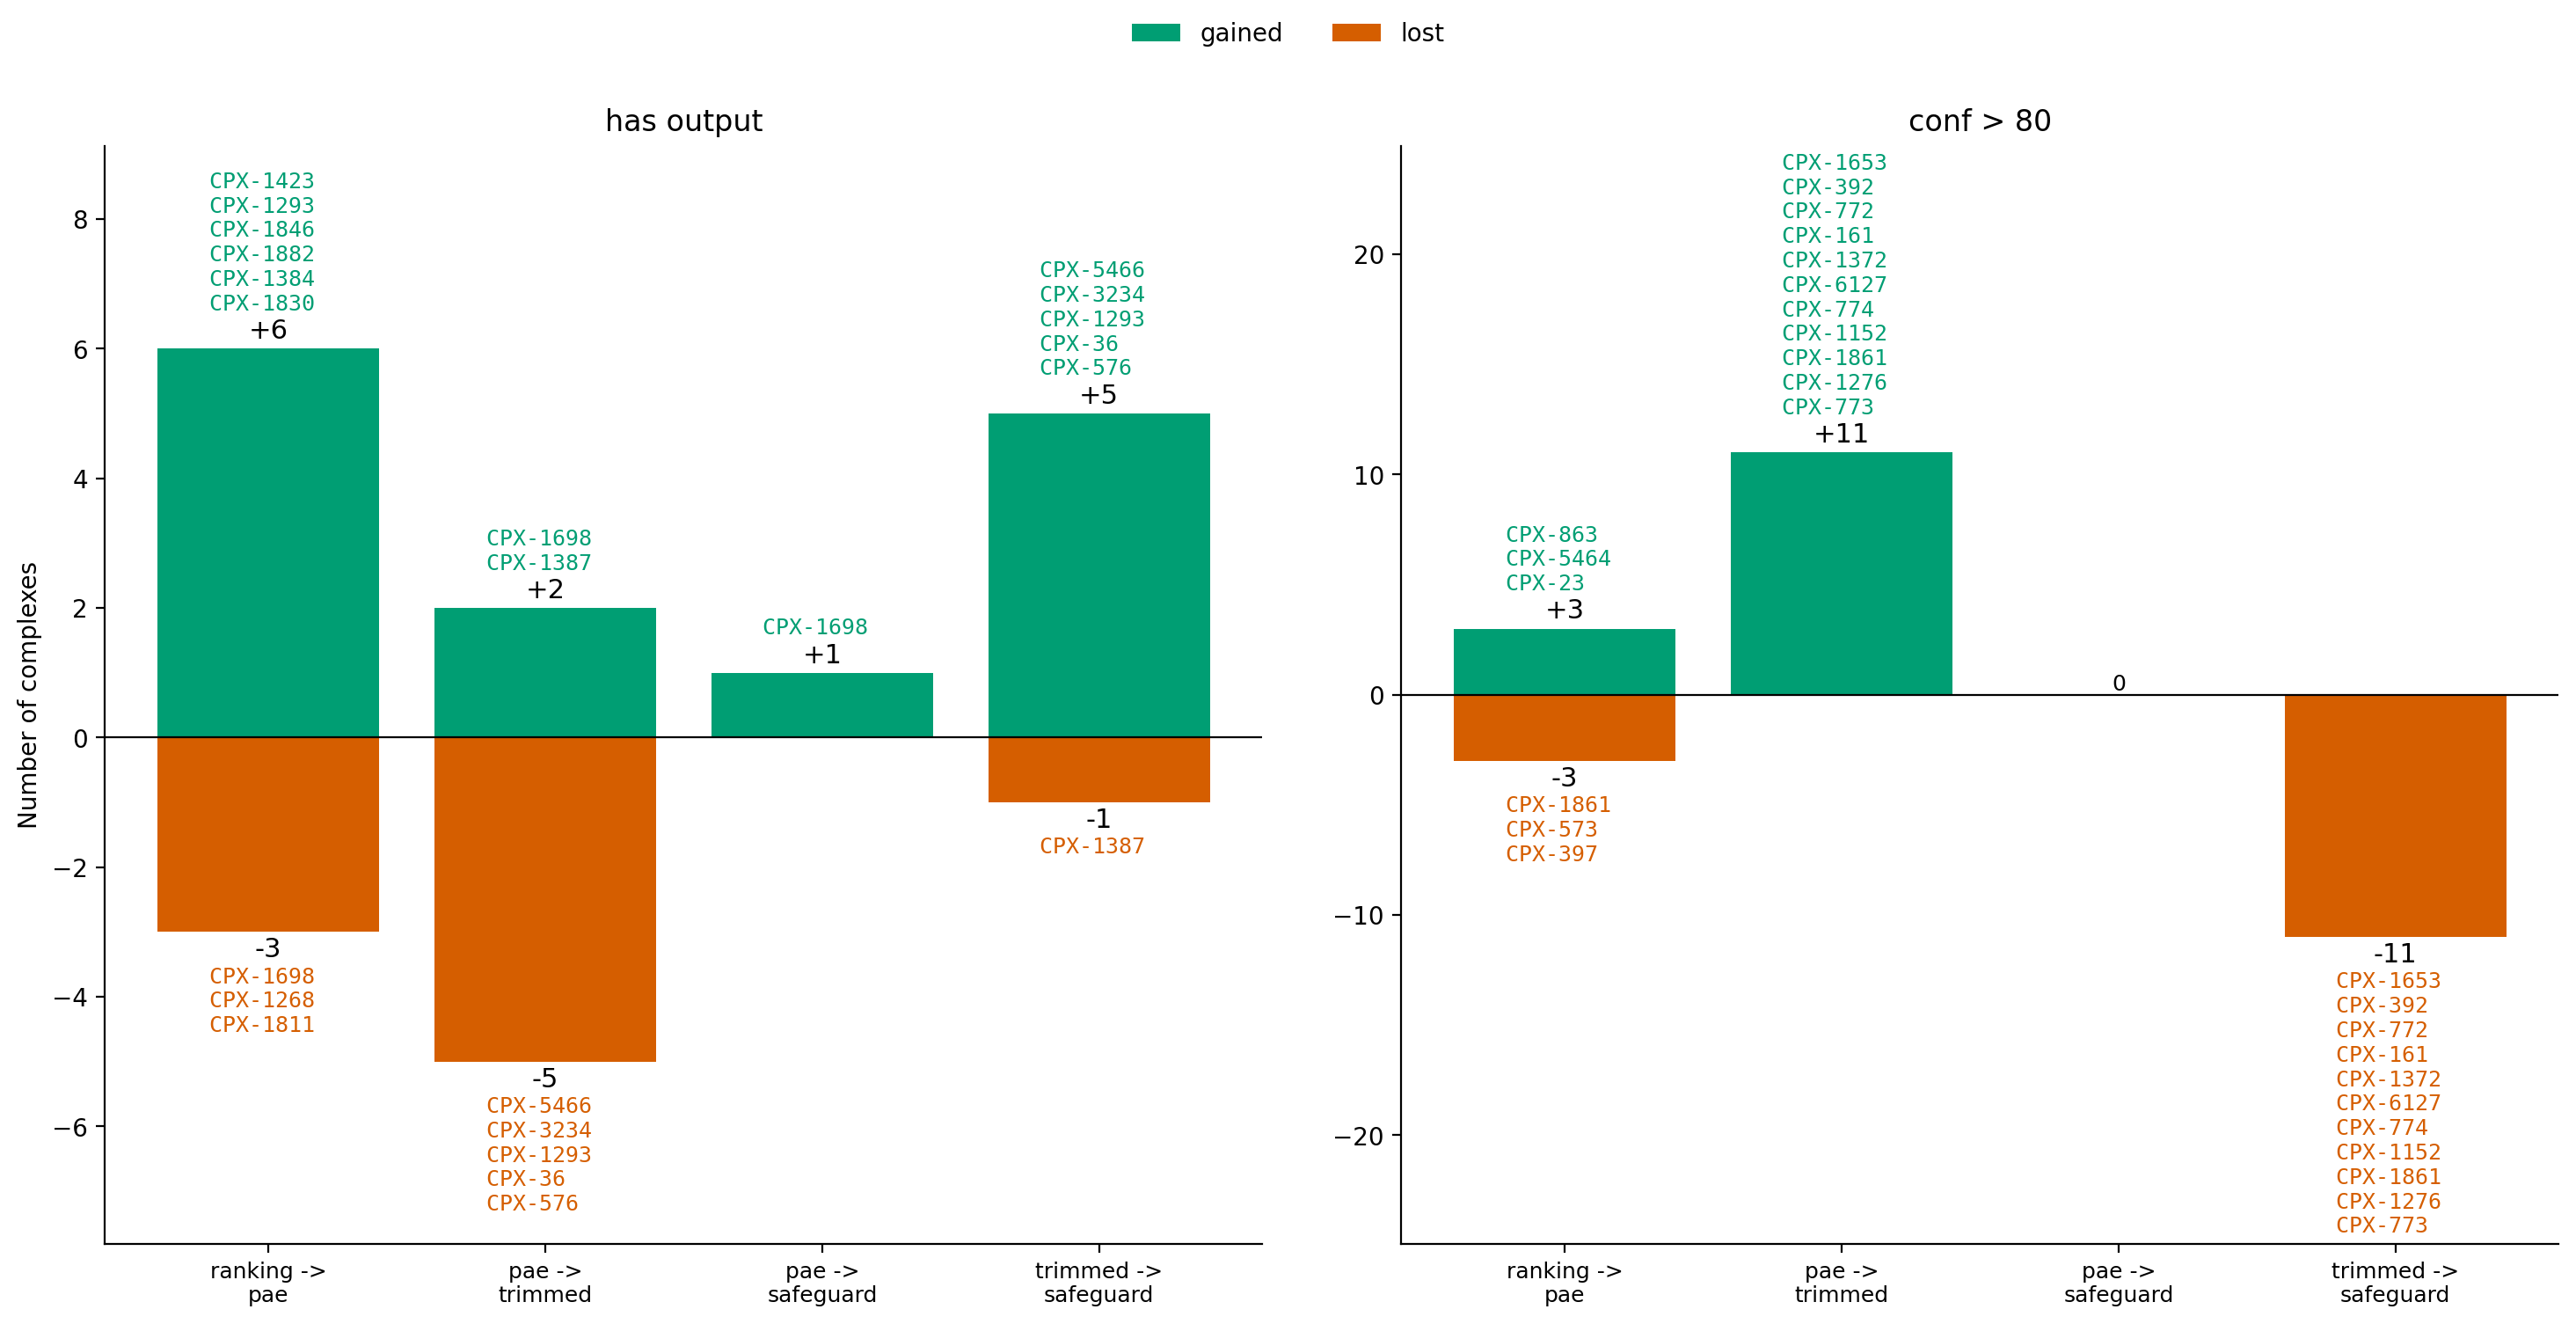

In [34]:
import ast, json, math, re
COMPARISONS = [   # ranking only against pae
    ("ranking", "pae"),
    ("pae", "trimmed"), ("pae", "safeguard"), ("trimmed", "safeguard"),
]

FIG_HEIGHT = 8          # inches
ID_FONTSIZE = 9
LINE_PT = 8.5           # height of one line of ids in points (a bit more than the fontsize)
ID_OFFSET_PT = 14       # space between the end of a bar and its ids (room for the "+n" / "-n" label)
ID_PAD_PT = 18          # extra space between the ids and the edge of the plot
TOP, BOTTOM = 0.90, 0.12    # axes position in the figure (fraction)


def format_ids(ids, max_per_column=12, max_columns=2):
    """complex ids as a text block, one id per line; split over 2 columns when there are many"""
    if not ids:
        return ""
    n_columns = min(max_columns, math.ceil(len(ids) / max_per_column))
    n_rows = math.ceil(len(ids) / n_columns)
    columns = [ids[c * n_rows:(c + 1) * n_rows] for c in range(n_columns)]    # highest confidence first
    return "\n".join(
        "  ".join(f"{column[row]:<9}" if row < len(column) else " " * 9 for column in columns)
        for row in range(n_rows)
    )


n_lines = lambda text: text.count("\n") + 1 if text else 0

fig, axes = plt.subplots(1, 2, figsize=(15, FIG_HEIGHT))
fig.subplots_adjust(left=0.06, right=0.99, bottom=BOTTOM, top=TOP, wspace=0.12)
axes_height_pt = FIG_HEIGHT * 72 * (TOP - BOTTOM)

for ax, test_name in zip(axes, tests):
    x = np.arange(len(COMPARISONS))
    gained_ids = [changes[(test_name, a, b)][0]["complex_ac"].to_list() for a, b in COMPARISONS]
    lost_ids = [changes[(test_name, a, b)][1]["complex_ac"].to_list() for a, b in COMPARISONS]
    n_gained = [len(ids) for ids in gained_ids]
    n_lost = [len(ids) for ids in lost_ids]

    up = ax.bar(x, n_gained, color="#009E73", label="gained")
    down = ax.bar(x, [-n for n in n_lost], color="#D55E00", label="lost")
    ax.bar_label(up, labels=[f"+{n}" if n else "" for n in n_gained], padding=2, fontsize=11)
    ax.bar_label(down, labels=[f"-{n}" if n else "" for n in n_lost], padding=2, fontsize=11)
    for xi, g, l in zip(x, n_gained, n_lost):
        if g == 0 and l == 0:
            ax.text(xi, 0, "0", ha="center", va="bottom", fontsize=9)

    # ids of the gained complexes above the bars, ids of the lost complexes below them
    gained_text = [format_ids(ids) for ids in gained_ids]
    lost_text = [format_ids(ids) for ids in lost_ids]
    text_style = dict(ha="center", fontsize=ID_FONTSIZE, family="monospace", multialignment="left", textcoords="offset points")
    for xi, n, text in zip(x, n_gained, gained_text):
        if text:
            ax.annotate(text, (xi, n), xytext=(0, ID_OFFSET_PT), va="bottom", color="#009E73", **text_style)
    for xi, n, text in zip(x, n_lost, lost_text):
        if text:
            ax.annotate(text, (xi, -n), xytext=(0, -ID_OFFSET_PT), va="top", color="#D55E00", **text_style)

    # make room for the ids: their height in points -> data units
    points_up = ID_OFFSET_PT + LINE_PT * max(n_lines(t) for t in gained_text) + ID_PAD_PT
    points_down = ID_OFFSET_PT + LINE_PT * max(n_lines(t) for t in lost_text) + ID_PAD_PT
    assert points_up + points_down < 0.9 * axes_height_pt, f"{test_name}: too many ids for the figure height"
    data_range = max(max(n_gained) + max(n_lost), 1) / (1 - (points_up + points_down) / axes_height_pt)
    ax.set_ylim(-max(n_lost) - data_range * points_down / axes_height_pt,
                max(n_gained) + data_range * points_up / axes_height_pt)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{a} ->\n{b}" for a, b in COMPARISONS], fontsize=9)
    ax.set_title(test_name)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Number of complexes")
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=2, frameon=False)
plt.show()

## How often i sthe correct stoichiometry also the one with the highest confidence?

In [36]:
import polars as pl
from pathlib import Path

# ---------------- paths ----------------
pipe = data_dir / "Pipeline"
runs = {
    "10_all_CP_complexes": pipe / "10_all_CP_complexes/all_pdb_present_10_all_CP_complexes_pool_pipeline_complexes_combfold_results.csv",
    "18_CP_model_based_on_pae": pipe / "18_CP_model_based_on_pae/all_pdb_present_18_CP_model_based_on_pae_pool_pipeline_complexes_combfold_results.csv",
    "19_CP_pae_plddt_trimmed": pipe / "19_CP_pae_plddt_trimmed/all_pdb_present_19_CP_pae_plddt_trimmed_pool_pipeline_complexes_combfold_results.csv",
    "20_CP_pae_plddt_trimmed_interface_safeguard": pipe / "20_CP_pae_plddt_trimmed_interface_safeguard/all_pdb_present_20_CP_pae_plddt_trimmed_interface_safeguard_pool_pipeline_complexes_combfold_results.csv",
}
tsv_path = data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv"

SOURCES = {"pred_1": "1", "pred_2": "2", "pred_3": "3", "true": "true"}  # source -> CF column suffix


# ---------------- helpers ----------------
def canon(expr: pl.Expr) -> pl.Expr:
    """'B:1,A:2' -> 'A:2,B:1' so stoichiometries can be compared as strings."""
    return expr.str.split(",").list.sort().list.join(",")


def pred_stoich(col: str) -> pl.Expr:
    # pred cell looks like '{"P1":1,"P2":2},{"rank":1,...}' -> keep only the first {...}
    return canon(pl.col(col).str.extract(r"^\{([^}]*)\}").str.replace_all('"', ""))


def best_conf(col: str) -> pl.Expr:
    # '{0: 65.5, 1: 68.0}' -> highest confidence over all assemblies (null if '{}')
    return (pl.col(col).str.extract_all(r": [\d.]+")
            .list.eval(pl.element().str.slice(2).cast(pl.Float64)).list.max())


def stoich_dict(s: str) -> dict:
    """'A:1,B:2' -> {'A': 1, 'B': 2} (rsplit: some IDs like CHEBI:123 contain a colon)"""
    return {acc: int(n) for acc, n in (p.rsplit(":", 1) for p in s.split(","))}


def is_multiple(best: str, true: str) -> bool:
    """True if best == k * true for an integer k >= 1 (k=1 is the exact match)."""
    b, t = stoich_dict(best), stoich_dict(true)
    if b.keys() != t.keys():
        return False
    k = b[next(iter(t))] // t[next(iter(t))]
    return k >= 1 and all(b[acc] == k * t[acc] for acc in t)


# ---------------- 1) complexes with known stoichiometry (no "(0)" in any molecule) ----------------
tsv = pl.read_csv(tsv_path, separator="\t")
known = (tsv.rename({"#Complex ac": "complex_ac", tsv.columns[4]: "identifiers"})
            .select("complex_ac", "identifiers")
            .filter(~pl.col("identifiers").str.contains(r"\(0\)")))


def load_known(path) -> pl.DataFrame:
    df = pl.read_csv(path).filter(pl.col("complex_ac").is_in(known["complex_ac"].implode()))
    assert (df["correct_pred_count"] != "unknown").all(), "known complex marked unknown in csv"
    return df


# ---------------- 2) per-run table ----------------
def analyse(df: pl.DataFrame) -> pl.DataFrame:
    """One row per complex: true stoich, stoich + confidence of every candidate, best candidate, correct?"""
    # true stoichiometry from identifiers: 'P1(1)|P2(2)' -> 'P1:1,P2:2'
    wide = df.select(
        "complex_ac", "identifiers",
        true_stoich=canon(pl.col("identifiers").str.replace_all(r"\((\d+)\)", ":$1").str.replace_all(r"\|", ",")),
        **{f"conf_{s}": best_conf(f"CF_{suffix}_confidence") for s, suffix in SOURCES.items()},
        **{f"stoich_{s}": pred_stoich(s) for s in SOURCES if s != "true"},
    ).with_columns(stoich_true=pl.col("true_stoich"))

    # long format (one row per complex x candidate) -> pick highest confidence (ties -> earlier source)
    long = pl.concat([
        wide.select("complex_ac", source=pl.lit(s), stoich=f"stoich_{s}", conf=f"conf_{s}")
        for s in SOURCES
    ])
    best = (long.drop_nulls("conf")                       # candidates without assembly have no confidence
            .sort("conf", descending=True, maintain_order=True)
            .unique("complex_ac", keep="first", maintain_order=True)
            .rename({"source": "best_source", "stoich": "best_stoich", "conf": "best_conf"}))

    return (wide.drop("stoich_true")
                .join(best, on="complex_ac", how="left")
                .with_columns(
                    best_is_correct=pl.col("best_stoich") == pl.col("true_stoich"),
                    best_is_correct_or_multiple=pl.struct("best_stoich", "true_stoich").map_elements(
                        lambda r: None if r["best_stoich"] is None else is_multiple(r["best_stoich"], r["true_stoich"]),
                        return_dtype=pl.Boolean)))


dfs = {name: load_known(p) for name, p in runs.items()}

# keep only complexes present (with known stoichiometry) in every run
common = set.intersection(*(set(d["complex_ac"]) for d in dfs.values()))
assert len(common) == 218, f"expected 218 shared complexes, got {len(common)}"
results = {name: analyse(d.filter(pl.col("complex_ac").is_in(list(common)))) for name, d in dfs.items()}

# drop complexes where no candidate had a confidence in ANY run (keeps runs comparable)
valid = set.intersection(*(set(r.filter(pl.col("best_source").is_not_null())["complex_ac"])
                           for r in results.values()))
results = {name: r.filter(pl.col("complex_ac").is_in(list(valid))) for name, r in results.items()}
assert all(r["best_is_correct"].null_count() == 0 and r["best_is_correct_or_multiple"].null_count() == 0
           for r in results.values())

# ---------------- 3) summary ----------------
for name, r in results.items():
    print(name, "| complexes:", r.height, "| exact:", r["best_is_correct"].sum(),
          "| exact or multiple:", r["best_is_correct_or_multiple"].sum())
    print(r.group_by("best_source").agg(n=pl.len(), correct=pl.col("best_is_correct").sum(),
                                         correct_or_multiple=pl.col("best_is_correct_or_multiple").sum()).sort("best_source"))

# ---------------- 4) one variable per run for Data Wrangler (needs pandas + pyarrow) ----------------
df_10, df_18, df_19, df_20 = (results[name].to_pandas() for name in runs)

10_all_CP_complexes | complexes: 199 | exact: 125 | exact or multiple: 125
shape: (4, 4)
┌─────────────┬─────┬─────────┬─────────────────────┐
│ best_source ┆ n   ┆ correct ┆ correct_or_multiple │
│ ---         ┆ --- ┆ ---     ┆ ---                 │
│ str         ┆ u32 ┆ u32     ┆ u32                 │
╞═════════════╪═════╪═════════╪═════════════════════╡
│ pred_1      ┆ 118 ┆ 82      ┆ 82                  │
│ pred_2      ┆ 27  ┆ 8       ┆ 8                   │
│ pred_3      ┆ 23  ┆ 4       ┆ 4                   │
│ true        ┆ 31  ┆ 31      ┆ 31                  │
└─────────────┴─────┴─────────┴─────────────────────┘
18_CP_model_based_on_pae | complexes: 199 | exact: 121 | exact or multiple: 122
shape: (4, 4)
┌─────────────┬─────┬─────────┬─────────────────────┐
│ best_source ┆ n   ┆ correct ┆ correct_or_multiple │
│ ---         ┆ --- ┆ ---     ┆ ---                 │
│ str         ┆ u32 ┆ u32     ┆ u32                 │
╞═════════════╪═════╪═════════╪═════════════════════╡
│ pred_

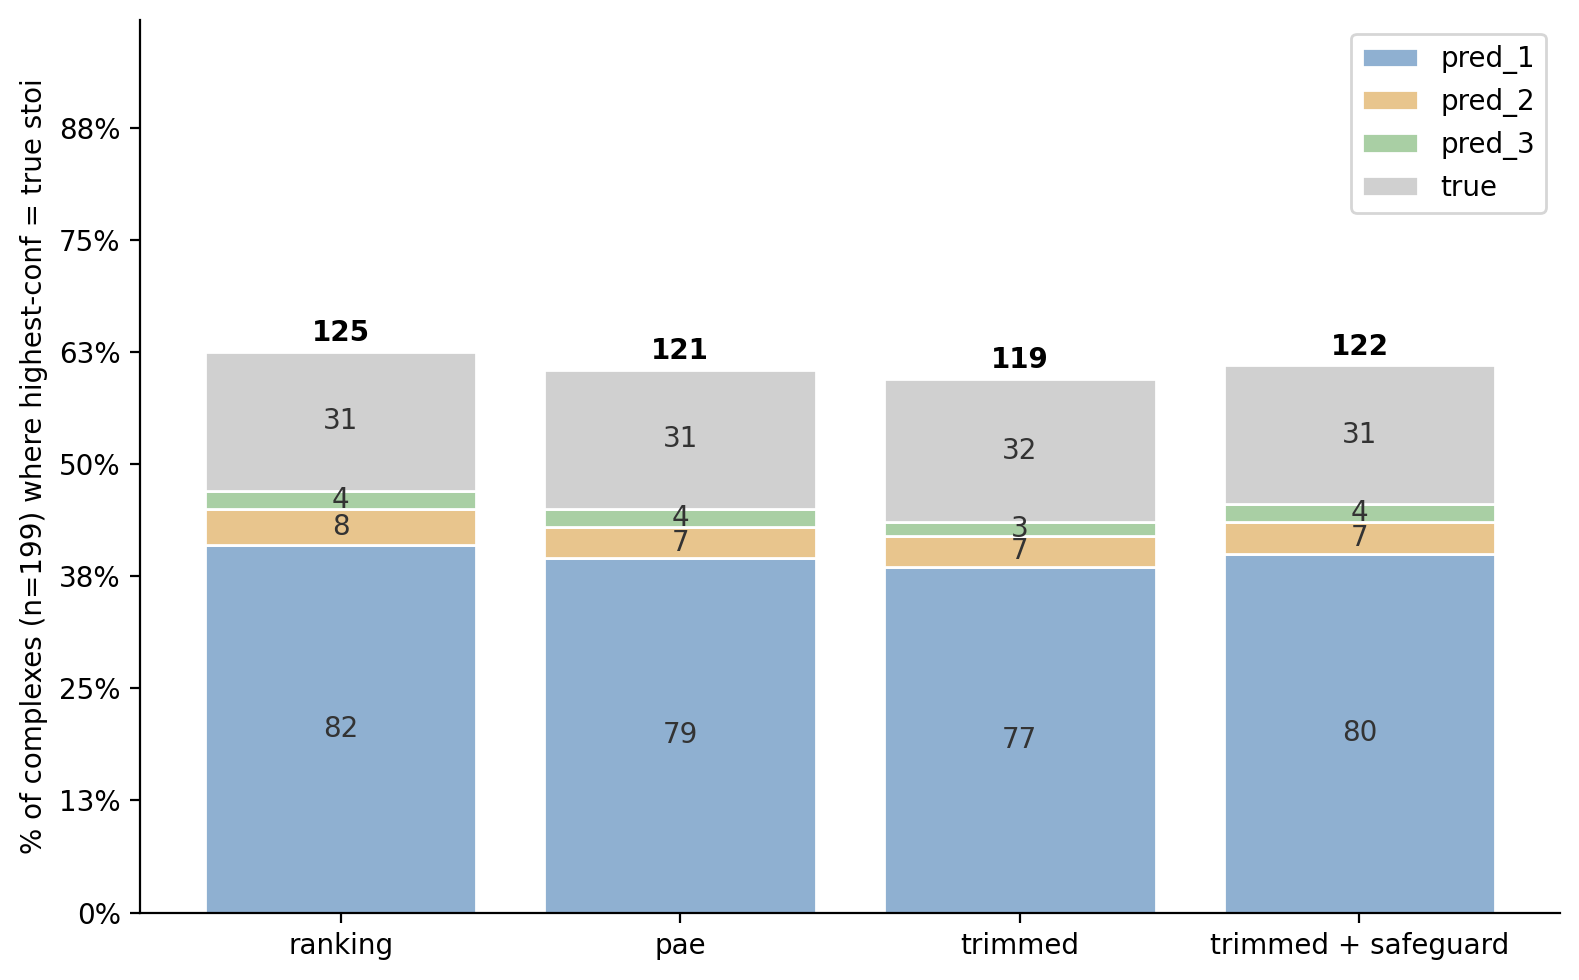

In [37]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
labels = ["ranking", "pae", "trimmed", "trimmed + safeguard"]
colors = {"pred_1": "#8fb0d1", "pred_2": "#e8c58d", "pred_3": "#a9cfa4", "true": "#d0d0d0"}  # muted

# per run: number of complexes where the highest-confidence candidate was correct, split by source
counts = {name: dict(r.filter(pl.col("best_is_correct")).group_by("best_source").len().iter_rows())
          for name, r in results.items()}
n_total = {r.height for r in results.values()}
assert len(n_total) == 1, "runs have different numbers of complexes"
n_total = n_total.pop()

fig, ax = plt.subplots(figsize=(8, 5))
bottom = [0] * len(runs)
for source in SOURCES:                                   # pred_1, pred_2, pred_3, true
    vals = [counts[name].get(source, 0) for name in runs]
    bars = ax.bar(labels, vals, bottom=bottom, label=source, color=colors[source], edgecolor="white")
    ax.bar_label(bars, labels=[v or "" for v in vals], label_type="center", color="#333333")
    bottom = [b + v for b, v in zip(bottom, vals)]

for i, total in enumerate(bottom):                       # total correct on top of each bar
    ax.text(i, total + 1, total, ha="center", va="bottom", fontweight="bold")

ax.set_ylim(0, n_total)                                  # 0-100 %
ax.yaxis.set_major_formatter(PercentFormatter(xmax=n_total))
ax.set_ylabel(f"% of complexes (n={n_total}) where highest-conf = true stoi")
ax.legend(loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## does trimming/ switching to pae changes stoichiometry with best confidence

does stoic predidct same stoi in all runs (ranking, pae and plddt,trimmed)

In [38]:
import itertools
import matplotlib.pyplot as plt
import polars as pl

# ---------------- config ----------------
pipe = data_dir / "Pipeline"
runs = {
    "10_all_CP_complexes": "ranking",
    "18_CP_model_based_on_pae": "pae",
    "19_CP_pae_plddt_trimmed": "trimmed",
    "20_CP_pae_plddt_trimmed_interface_safeguard": "trimmed_safeguard",
}
keys = list(runs.values())
N_PROTEINS_ABOVE = 2
GROUPS = {
    "benchmark": ["exact_pdb_match"],
    "no_structure": ["no_homology_match", "no_sufficient_match"],
}
class_to_group = {c: g for g, cs in GROUPS.items() for c in cs}



In [39]:
# ---------------- helpers ----------------
def pred_stoich(col: str) -> pl.Expr:
    """pred cell '{"P1":1,"P2":2},{"rank":1,...}' -> 'P1:1,P2:2' (sorted)"""
    first_dict = pl.col(col).str.extract(r"^\{([^}]*)\}").str.replace_all('"', "")
    return first_dict.str.split(",").list.sort().list.join(",")


def best_conf(col: str) -> pl.Expr:
    """'{0: 65.5, 1: 68.0}' -> 68.0 (best assembly); '{}' -> null"""
    return (pl.col(col).str.extract_all(r": [\d.]+")
            .list.eval(pl.element().str.slice(2).cast(pl.Float64)).list.max())


def load_preds(folder: str, run: str) -> pl.DataFrame:
    """Long format: one row per (complex, pred_1/2/3) with stoichiometry and best CombFold confidence."""
    path = pipe / folder / f"all_pdb_present_{folder}_pool_pipeline_complexes_combfold_results.csv"
    assert path.exists(), f"missing results file: {path}"
    df = pl.read_csv(path)
    assert df["complex_ac"].is_unique().all(), f"duplicate complexes in {run}"
    return pl.concat([
        df.select("complex_ac", pred=pl.lit(f"pred_{i}"), stoich=pred_stoich(f"pred_{i}"),
                  conf=best_conf(f"CF_{i}_confidence"), run=pl.lit(run))
        for i in (1, 2, 3)
    ])



In [40]:
# ---------------- 1) complex groups (benchmark / no structure) ----------------
mapping = pl.read_csv(data_dir / "complete_complex_pdb_mapping_v2/all_pdb_matches_with_match_class.csv")
unknown = set(class_to_group) - set(mapping["match_class"].unique())
assert not unknown, f"match_class not found in mapping: {unknown}"

kept_df = (mapping.filter(pl.col("match_class").is_in(list(class_to_group)) & (pl.col("n_proteins") > N_PROTEINS_ABOVE))
                  .select("complex_ac", "match_class").unique()
                  .with_columns(group=pl.col("match_class").replace_strict(class_to_group)))
assert kept_df["complex_ac"].is_unique().all(), "a complex has several match classes"

# ---------------- 2) load all runs, keep complexes in all runs ----------------
allp = (pl.concat([load_preds(folder, run) for folder, run in runs.items()])
          .filter(pl.col("complex_ac").is_in(kept_df["complex_ac"].implode())))

in_all_runs = (allp.group_by("complex_ac").agg(pl.col("run").n_unique())
                   .filter(pl.col("run") == len(runs))["complex_ac"])
print(f"{allp['complex_ac'].n_unique() - len(in_all_runs)} complexes missing from at least one run (excluded)")
allp = allp.filter(pl.col("complex_ac").is_in(in_all_runs.implode()))

# ---------------- 3) best (highest-confidence) pred per complex and run ----------------
best = (allp.drop_nulls("conf")                 # preds without an assembly can't win
            .sort("conf", descending=True, maintain_order=True)   # ties -> lower pred
            .unique(subset=["complex_ac", "run"], keep="first", maintain_order=True))
has_best = (best.group_by("complex_ac").agg(pl.col("run").n_unique())
                .filter(pl.col("run") == len(runs))["complex_ac"])
print(f"{len(in_all_runs) - len(has_best)} complexes have no scored pred in at least one run (excluded)")
best = best.filter(pl.col("complex_ac").is_in(has_best.implode()))

# ---------------- 4) keep complexes whose pred_1/2/3 are identical in all runs ----------------
identical = (allp.group_by("complex_ac", "pred").agg(n=pl.col("stoich").n_unique())
                 .group_by("complex_ac").agg(ok=(pl.col("n") == 1).all())
                 .filter(pl.col("ok"))["complex_ac"])
best = best.filter(pl.col("complex_ac").is_in(identical.implode()))

# ---------------- 5) one row per complex ----------------
table = best.pivot(on="run", index="complex_ac", values=["pred", "conf", "stoich"])
top_run = (best.sort("conf", descending=True, maintain_order=True)          # ties -> earlier run
               .unique(subset="complex_ac", keep="first", maintain_order=True)
               .select("complex_ac", highest_conf_run="run"))
table = table.join(top_run, on="complex_ac").join(kept_df, on="complex_ac")

count_by_class = lambda acs: (acs.to_frame().join(kept_df, on="complex_ac")
                                .group_by("group", "match_class").len().sort("group", "match_class"))
print("complexes in the groups:");  print(count_by_class(kept_df["complex_ac"]))
print("kept for the comparison:");  print(count_by_class(table["complex_ac"]))
print(table.group_by("group", "highest_conf_run").len().sort("group", "highest_conf_run"))



0 complexes missing from at least one run (excluded)
32 complexes have no scored pred in at least one run (excluded)
complexes in the groups:
shape: (3, 3)
┌──────────────┬─────────────────────┬─────┐
│ group        ┆ match_class         ┆ len │
│ ---          ┆ ---                 ┆ --- │
│ str          ┆ str                 ┆ u32 │
╞══════════════╪═════════════════════╪═════╡
│ benchmark    ┆ exact_pdb_match     ┆ 71  │
│ no_structure ┆ no_homology_match   ┆ 24  │
│ no_structure ┆ no_sufficient_match ┆ 183 │
└──────────────┴─────────────────────┴─────┘
kept for the comparison:
shape: (3, 3)
┌──────────────┬─────────────────────┬─────┐
│ group        ┆ match_class         ┆ len │
│ ---          ┆ ---                 ┆ --- │
│ str          ┆ str                 ┆ u32 │
╞══════════════╪═════════════════════╪═════╡
│ benchmark    ┆ exact_pdb_match     ┆ 62  │
│ no_structure ┆ no_homology_match   ┆ 20  │
│ no_structure ┆ no_sufficient_match ┆ 145 │
└──────────────┴─────────────────────┴──

In [41]:
# ---------------- 5b) true stoichiometry per complex (same canonical string format as stoich_<run>) ----------------
complextab_raw = pl.read_csv(tsv_path, separator="\t")
true_stoich_per_complex = (
    complextab_raw
    .rename({"#Complex ac": "complex_ac", complextab_raw.columns[4]: "identifiers"})
    .select(
        "complex_ac",
        true_stoich=canon(pl.col("identifiers").str.replace_all(r"\((\d+)\)", ":$1").str.replace_all(r"\|", ",")),
        stoich_is_known=~pl.col("identifiers").str.contains(r"\(0\)"),
    )
)
assert true_stoich_per_complex["complex_ac"].is_unique().all(), "duplicate complex_ac in the ComplexTab"

table = table.join(true_stoich_per_complex, on="complex_ac", how="left")
assert table["true_stoich"].null_count() == 0, "complexes in `table` missing from the ComplexTab"

# complexes with unknown stoichiometry ("(0)") cannot be judged correct/incorrect -> drop from both groups
print("dropping complexes with unknown stoichiometry:")
print(table.filter(~pl.col("stoich_is_known")).group_by("group").len().sort("group"))
table = table.filter(pl.col("stoich_is_known"))
assert table["stoich_is_known"].all()
print("remaining:")
print(table.group_by("group").len().sort("group"))

dropping complexes with unknown stoichiometry:
shape: (2, 2)
┌──────────────┬─────┐
│ group        ┆ len │
│ ---          ┆ --- │
│ str          ┆ u32 │
╞══════════════╪═════╡
│ benchmark    ┆ 18  │
│ no_structure ┆ 111 │
└──────────────┴─────┘
remaining:
shape: (2, 2)
┌──────────────┬─────┐
│ group        ┆ len │
│ ---          ┆ --- │
│ str          ┆ u32 │
╞══════════════╪═════╡
│ benchmark    ┆ 44  │
│ no_structure ┆ 54  │
└──────────────┴─────┘


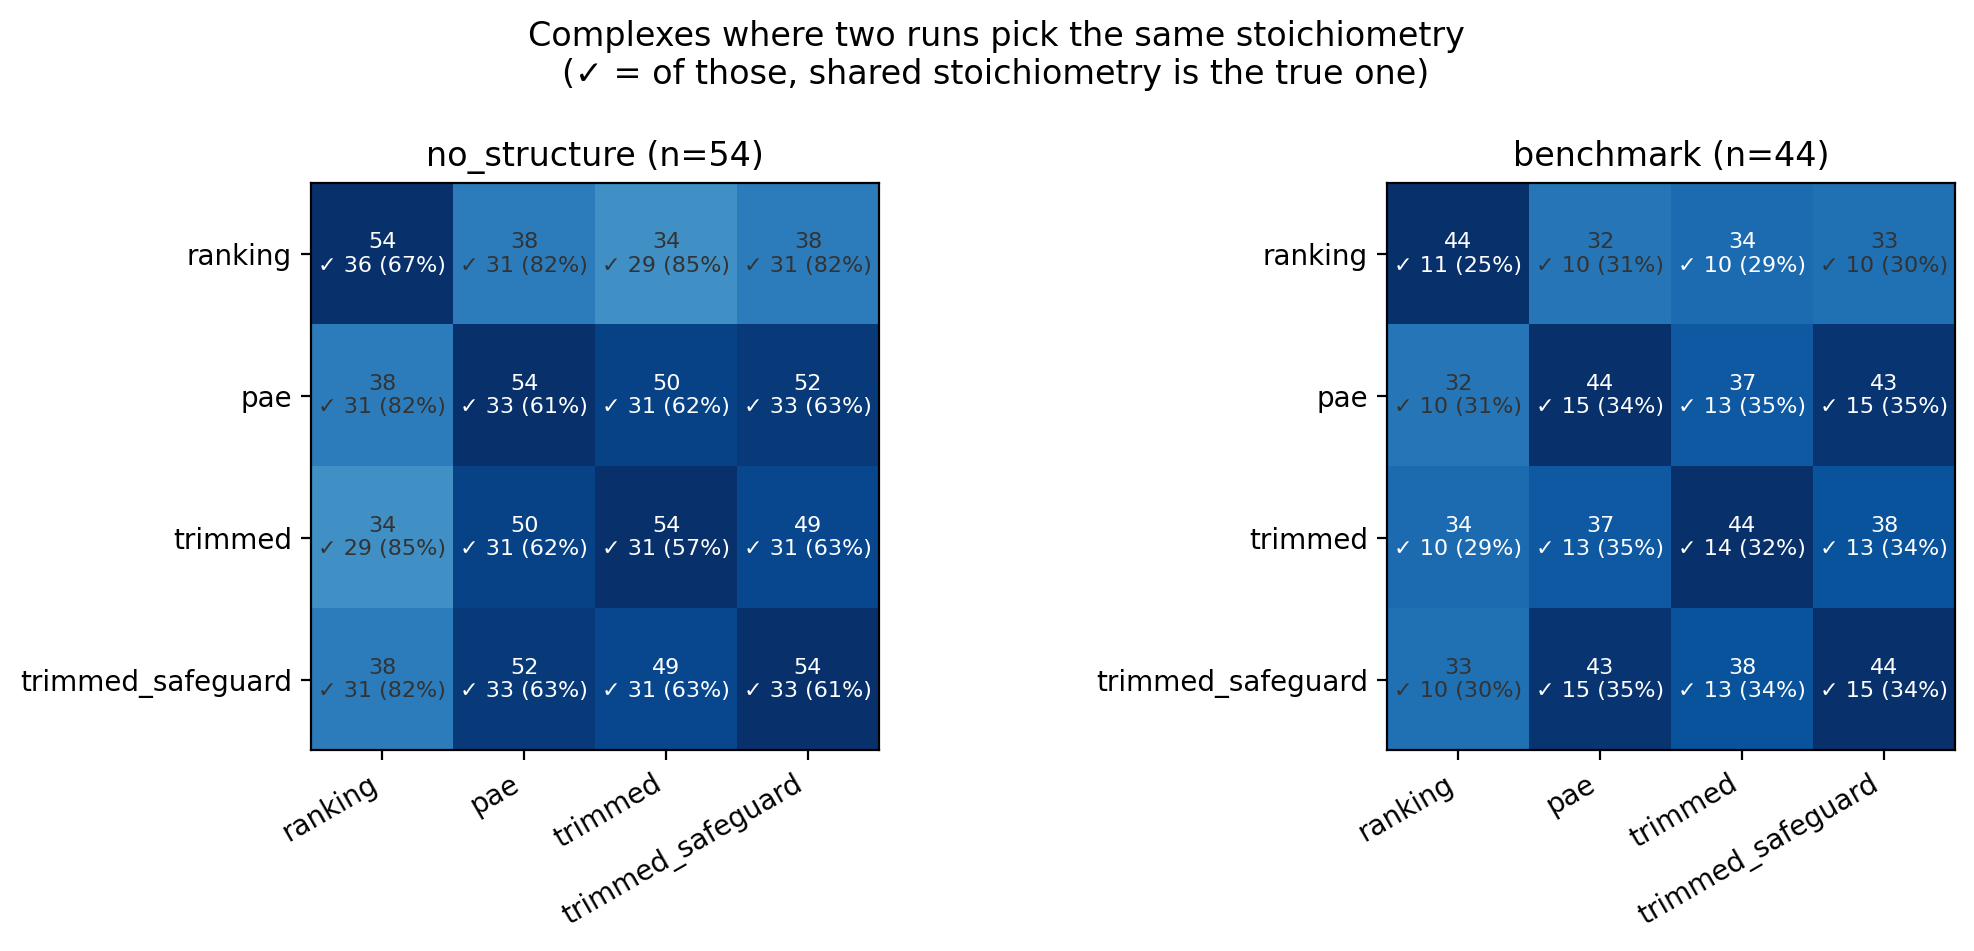

In [42]:
# ---------------- 6) heatmap: same best stoichiometry between runs (+ how many of those are correct) ----------------
GROUP_ORDER = ["no_structure", "benchmark"]
assert set(GROUP_ORDER) == set(table["group"].unique()), "groups in `table` differ from GROUP_ORDER"

fig, axes = plt.subplots(1, len(GROUP_ORDER), figsize=(11, 4.8))
for ax, group in zip(axes, GROUP_ORDER):
    group_table = table.filter(pl.col("group") == group)
    n_complexes = group_table.height

    shared_counts = [
        [group_table.filter(pl.col(f"stoich_{run_a}") == pl.col(f"stoich_{run_b}")).height for run_b in keys]
        for run_a in keys
    ]
    shared_and_correct_counts = [
        [group_table.filter(
            (pl.col(f"stoich_{run_a}") == pl.col(f"stoich_{run_b}"))
            & (pl.col(f"stoich_{run_a}") == pl.col("true_stoich"))
        ).height for run_b in keys]
        for run_a in keys
    ]
    # sanity: correct can never exceed shared
    assert all(c <= s for rc, rs in zip(shared_and_correct_counts, shared_counts) for c, s in zip(rc, rs))

    ax.imshow([[s / n_complexes for s in row] for row in shared_counts], vmin=0, vmax=1, cmap="Blues")
    for i, row in enumerate(shared_counts):
        for j, n_shared in enumerate(row):
            n_correct = shared_and_correct_counts[i][j]
            # if two runs share no stoichiometry at all, there is nothing to take a percentage of
            percent_correct = f"{n_correct / n_shared:.0%}" if n_shared > 0 else "n/a"
            ax.text(j, i, f"{n_shared}\n✓ {n_correct} ({percent_correct})",
                    ha="center", va="center", fontsize=8,
                    color="white" if n_shared / n_complexes > 0.75 else "#333333")
    ax.set_xticks(range(len(keys)), keys, rotation=30, ha="right")
    ax.set_yticks(range(len(keys)), keys)
    ax.set_title(f"{group} (n={n_complexes})")
fig.suptitle("Complexes where two runs pick the same stoichiometry\n(✓ = of those, shared stoichiometry is the true one)")
plt.tight_layout()
plt.show()

In [43]:
# ---------------- diagnostics: where do complexes drop out, and is the true stoichiometry even proposed? ----------------
# 1) funnel: how many complexes per group survive each filter
funnel_stages = [
    ("mapping: group + >2 proteins", None),
    ("present in all 4 runs", in_all_runs),
    ("has a scored pred in every run", has_best),
    ("pred_1/2/3 identical across runs", identical),
    ("stoichiometry known (no '(0)')", true_stoich_per_complex.filter(pl.col("stoich_is_known"))["complex_ac"]),
]
remaining_complexes = kept_df
funnel_parts = []
for stage_name, stage_complexes in funnel_stages:
    if stage_complexes is not None:
        remaining_complexes = remaining_complexes.filter(pl.col("complex_ac").is_in(stage_complexes.implode()))
    funnel_parts.append(remaining_complexes.group_by("group").len().with_columns(stage=pl.lit(stage_name)))
funnel_counts = pl.concat(funnel_parts).pivot(on="group", index="stage", values="len", sort_columns=True)
assert remaining_complexes.height == table.height, "funnel does not end at the complexes in `table`"
print(funnel_counts)

# 2) upper bound: does any of pred_1/2/3 equal the true stoichiometry?
true_stoich_available = (
    allp.filter(pl.col("complex_ac").is_in(table["complex_ac"].implode()))
    .join(true_stoich_per_complex.select("complex_ac", "true_stoich"), on="complex_ac")
    .group_by("complex_ac", "run")
    .agg(true_among_candidates=(pl.col("stoich") == pl.col("true_stoich")).any())
    .join(table.select("complex_ac", "group"), on="complex_ac")
    .group_by("group", "run")
    .agg(n_complexes=pl.len(), n_true_proposed=pl.col("true_among_candidates").sum())
    .sort("group", "run")
)
print(true_stoich_available)

# 3) how complicated is the true stoichiometry per group?
true_stoich_complexity = (
    table
    .with_columns(
        copies_per_protein=pl.col("true_stoich").str.split(",").list.eval(
            pl.element().str.extract(r":(\d+)$", 1).cast(pl.Int64)
        )
    )
    .group_by("group")
    .agg(
        n_complexes=pl.len(),
        median_total_subunits=pl.col("copies_per_protein").list.sum().median(),
        median_max_copies=pl.col("copies_per_protein").list.max().median(),
        share_all_ones=(pl.col("copies_per_protein").list.max() == 1).mean(),
    )
)
print(true_stoich_complexity)

shape: (5, 3)
┌─────────────────────────────────┬───────────┬──────────────┐
│ stage                           ┆ benchmark ┆ no_structure │
│ ---                             ┆ ---       ┆ ---          │
│ str                             ┆ u32       ┆ u32          │
╞═════════════════════════════════╪═══════════╪══════════════╡
│ mapping: group + >2 proteins    ┆ 71        ┆ 207          │
│ present in all 4 runs           ┆ 69        ┆ 194          │
│ has a scored pred in every run  ┆ 63        ┆ 168          │
│ pred_1/2/3 identical across ru… ┆ 62        ┆ 165          │
│ stoichiometry known (no '(0)')  ┆ 44        ┆ 54           │
└─────────────────────────────────┴───────────┴──────────────┘
shape: (8, 4)
┌──────────────┬───────────────────┬─────────────┬─────────────────┐
│ group        ┆ run               ┆ n_complexes ┆ n_true_proposed │
│ ---          ┆ ---               ┆ ---         ┆ ---             │
│ str          ┆ str               ┆ u32         ┆ u32             │
╞══

278 complexes in the groups, 263 of them in all csvs


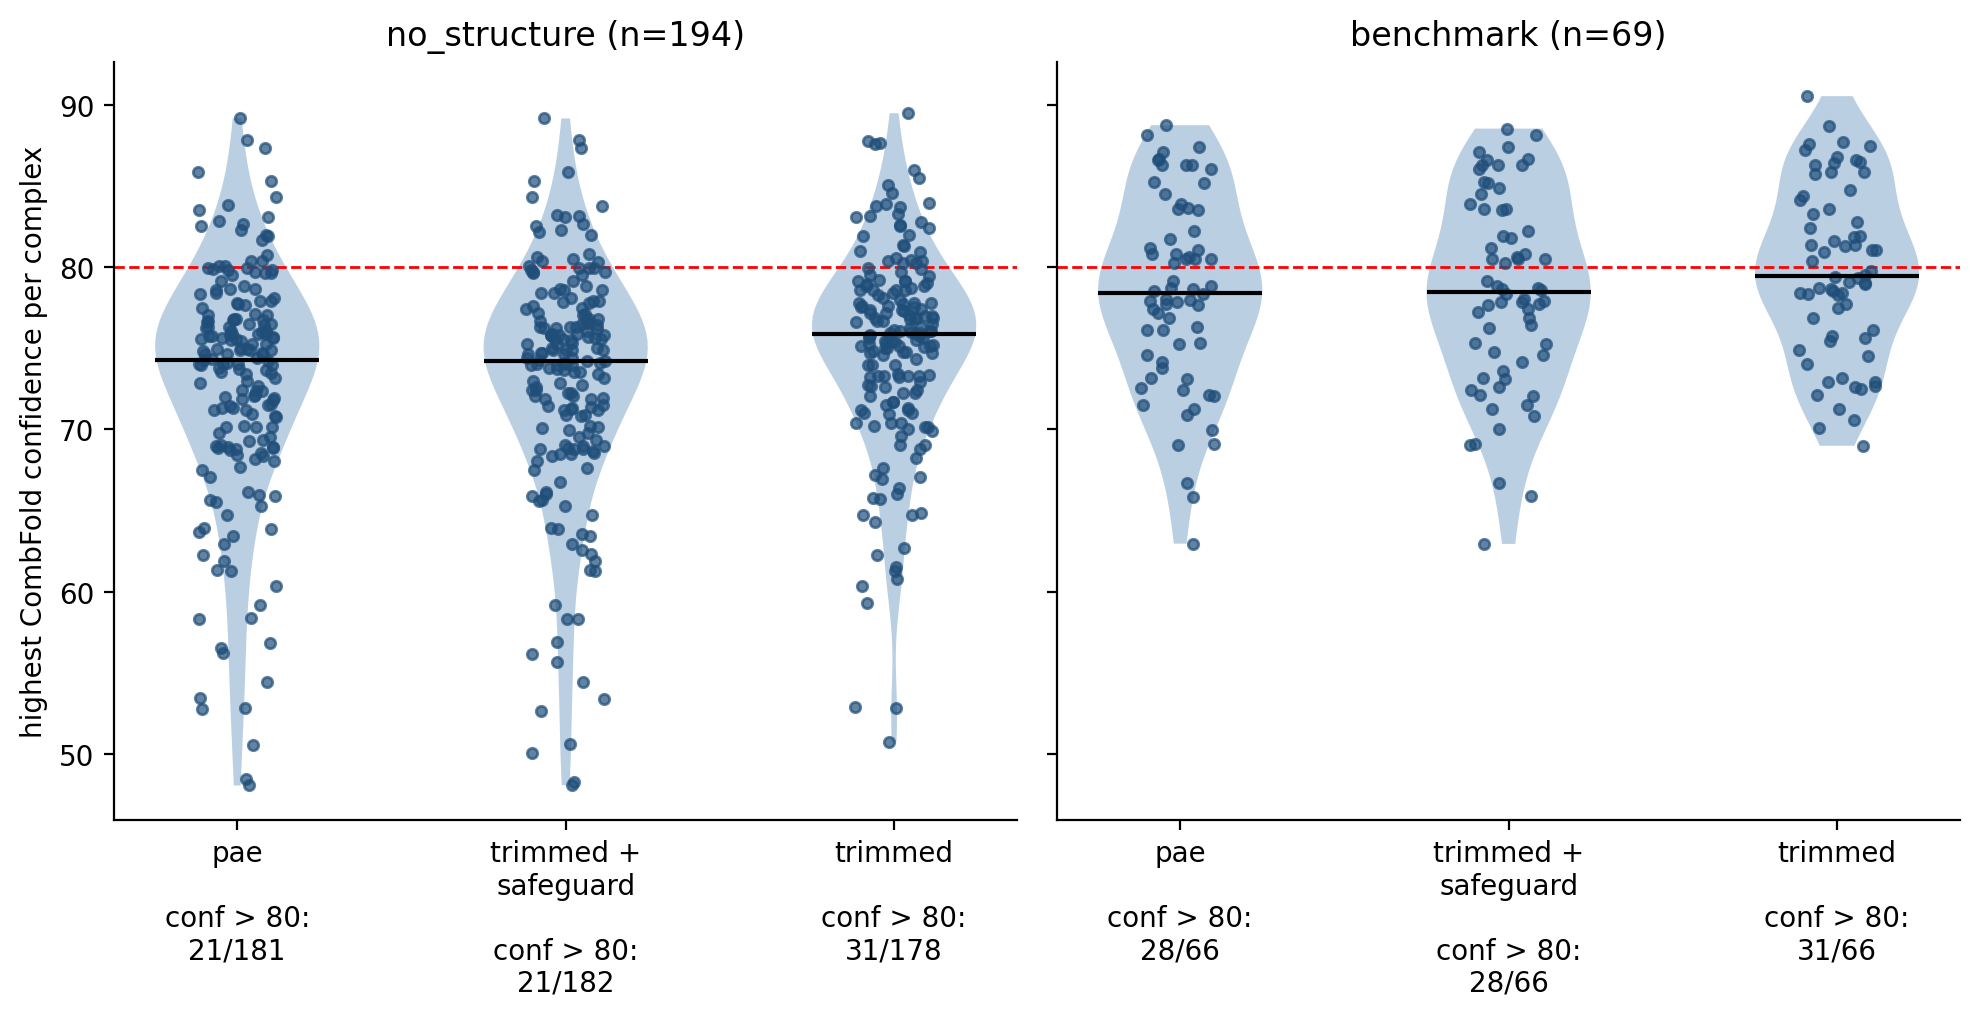

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

# ---------------- config ----------------
CONF_THRESHOLD = 80
N_PROTEINS_ABOVE = 2        # keep complexes with MORE than this many proteins
VIOLIN_RUNS = {             # violin order: name -> pipeline folder
    "pae": "18_CP_model_based_on_pae",
    "trimmed_safeguard": "20_CP_pae_plddt_trimmed_interface_safeguard",
    "trimmed": "19_CP_pae_plddt_trimmed",
}
tick_names = {"pae": "pae", "trimmed_safeguard": "trimmed +\nsafeguard", "trimmed": "trimmed"}
GROUPS = {
    "no_structure": ["no_homology_match", "no_sufficient_match"],
    "benchmark": ["exact_pdb_match"],
}
class_to_group = {c: g for g, cs in GROUPS.items() for c in cs}


# ---------------- 1) complexes per group ----------------
mapping = pl.read_csv(data_dir / "complete_complex_pdb_mapping_v2/all_pdb_matches_with_match_class.csv")
unknown = set(class_to_group) - set(mapping["match_class"].unique())
assert not unknown, f"match_class not found in mapping: {unknown}"

groups_df = (mapping.filter(pl.col("match_class").is_in(list(class_to_group)) & (pl.col("n_proteins") > N_PROTEINS_ABOVE))
                    .select("complex_ac", "match_class").unique()
                    .with_columns(group=pl.col("match_class").replace_strict(class_to_group)))
assert groups_df["complex_ac"].is_unique().all(), "a complex has several match classes"


# ---------------- 2) highest confidence per complex and run ----------------
def best_conf(col: str) -> pl.Expr:
    """'{0: 65.5, 1: 68.0}' -> 68.0 (best assembly); '{}' -> null"""
    return (pl.col(col).str.extract_all(r": [\d.]+")
            .list.eval(pl.element().str.slice(2).cast(pl.Float64)).list.max())


def best_confidence(run: str, folder: str) -> pl.DataFrame:
    """Best of pred_1/2/3, plus the true stoichiometry if no pred matched it (null = no output)."""
    path = data_dir / "Pipeline" / folder / f"all_pdb_present_{folder}_pool_pipeline_complexes_combfold_results.csv"
    assert path.exists(), f"missing results file: {path}"
    df = pl.read_csv(path).join(groups_df, on="complex_ac", how="inner")
    assert df["complex_ac"].is_unique().all(), f"{run}: more than one row per complex"
    return df.select(
        "complex_ac",
        pl.max_horizontal(
            best_conf("CF_1_confidence"), best_conf("CF_2_confidence"), best_conf("CF_3_confidence"),
            pl.when(pl.col("correct_pred_rank") == "none").then(best_conf("CF_true_confidence")),
        ).alias(run),
    )


per_run = {run: best_confidence(run, folder) for run, folder in VIOLIN_RUNS.items()}
violin_table = groups_df
for run, df in per_run.items():
    violin_table = violin_table.join(df, on="complex_ac", how="inner")
for run, df in per_run.items():       # inner joins must not silently drop complexes
    assert df.height == violin_table.height, f"{run}: csv has other complexes than the other runs"
print(f"{groups_df.height} complexes in the groups, {violin_table.height} of them in all csvs")


# ---------------- 3) violin plot ----------------
rng = np.random.default_rng(0)                # fixed seed -> same dot jitter every time

fig, axes = plt.subplots(1, len(GROUPS), figsize=(10, 5.2), sharey=True)
for ax, group in zip(axes, GROUPS):
    t = violin_table.filter(pl.col("group") == group)
    data = [t[run].drop_nulls().to_list() for run in VIOLIN_RUNS]      # complexes with output only
    violins = ax.violinplot(data, showextrema=False)
    for body in violins["bodies"]:
        body.set_facecolor("#8fb0d1")
        body.set_alpha(0.6)
    for i, vals in enumerate(data, start=1):
        ax.scatter(i + rng.uniform(-0.12, 0.12, len(vals)), vals, s=14, color="#1f4e79", alpha=0.7, zorder=3)
        ax.hlines(np.median(vals), i - 0.25, i + 0.25, color="black", zorder=4)
    ax.axhline(CONF_THRESHOLD, color="red", linestyle="--", linewidth=1, zorder=2)

    n_above = [sum(v > CONF_THRESHOLD for v in vals) for vals in data]
    ax.set_xticks(range(1, len(VIOLIN_RUNS) + 1),
                  [f"{tick_names[run]}\n\nconf > {CONF_THRESHOLD}:\n{n}/{len(vals)}"
                   for run, n, vals in zip(VIOLIN_RUNS, n_above, data)])
    ax.set_title(f"{group} (n={t.height})")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("highest CombFold confidence per complex")
plt.tight_layout()
plt.show()

## How are the new protein placed

sanity check mmseq

In [ ]:
pae = "Pipeline/18_CP_model_based_on_pae/CombFold/O13539x1_P17629x1_P33441x1_P53552x1_P53851x1_pool_output/assembled_results/output_clustered_0.pdb" # 80.5098

pae_trimmed = "Pipeline/19_CP_pae_plddt_trimmed/CombFold/O13539x1_P17629x1_P33441x1_P53552x1_P53851x1_pool_output/assembled_results/output_clustered_0.pdb" #81.3475

USALIGN_BIN = "/cluster/project/beltrao/kdammer/master_thesis/tools/usalign/USalign/USalign"


In [ ]:
def run_usalign(pdb_1, pdb_2, mm=1, ter=0):
    """US-align of two complexes (structure 1 is superimposed onto structure 2); returns the full text output"""
    for pdb in (pdb_1, pdb_2):
        assert Path(pdb).exists(), f"missing: {pdb}"
    command = [USALIGN_BIN, str(pdb_1), str(pdb_2), "-mm", str(mm), "-ter", str(ter)]
    return subprocess.run(command, capture_output=True, text=True, check=True).stdout


print(run_usalign(pae_pdb, pae_trimmed_pdb))

#usalign_metrics = run_usalign(pae_pdb, pae_trimmed_pdb)
#print(usalign_metrics)
"""
********************************************************************
 * US-align (Version 20260813)                                      *
 * Universal Structure Alignment of Proteins and Nucleic Acids      *
 * Reference: C Zhang, L Freddolino, Y Zhang. (2026) Nat Protoc     *
 *            C Zhang, M Shine, AM Pyle, Y Zhang. (2022) Nat Methods*
 *            C Zhang, AM Pyle (2022) iScience.                     *
 * Please email comments and suggestions to zhang@zhanggroup.org    *
 ********************************************************************

Name of Structure_1: /cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/18_CP_model_based_on_pae/CombFold/O13539x1_P17629x1_P33441x1_P53552x1_P53851x1_pool_output/assembled_results/output_clustered_0.pdb:1,A:1,C:1,B:1,D:1,E (to be superimposed onto Structure_2)
Name of Structure_2: /cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/19_CP_pae_plddt_trimmed/CombFold/O13539x1_P17629x1_P33441x1_P53552x1_P53851x1_pool_output/assembled_results/output_clustered_0.pdb:1,A:1,C:1,B:1,D:1,E
Length of Structure_1: 3424 residues
Length of Structure_2: 2957 residues

Aligned length= 2957, RMSD=   1.48, Seq_ID=n_identical/n_aligned= 1.000
TM-score= 0.85715 (normalized by length of Structure_1: L=3424, d0=16.86)
TM-score= 0.99168 (normalized by length of Structure_2: L=2957, d0=15.97)
(You should use TM-score normalized by length of the reference structure)

(":" denotes residue pairs of d < 5.0 Angstrom, "." denotes other aligned residues)
MTKEEGRTYFESLCEEEQSLQESQTHLLNILDILSVLADPRSSDDLLTESLKKLPDLHRELINSSIRLRYDKYQTREAQLLEDTKTGRDVAAGVQNPKSISEYYSTFEHLNRDTLRYINLLKRLSVDLAKQVEVSDPSVTVYEMDKWVPSEKLQGILEQYCAPDTDIRGVDAQIKNYLDQIKMARAKFGLENKYSLKERLSTLTKELNHWRKEWDDIEMLMFGDDAHSMKKMIQKIDSLKSEINAPSESYPVDKEGDIVLE*MPLSQKQIDQVRTKVHYSEVDTPFNKYLDILGKVTKLTGSIINGTLSNDDSKIEKLTEQNISQLKESAHLRFLDLQSSIDTKKVADENWETCQQETLAKLENLKDKLPDIKSIHSKLLLRIGKLQGLYDSVQVINREVEGLSEGRTSLVVTRAEWEKELGTDLVKFLIEKNYLKLVDPGLKKDSSEERYRIYDDFSKGPKELESINASMKSDIENVRQEVSSYKEKWLRDAEIFGKITSIFKEELLKRDGLLNEAEGDNIDEDYESDEDEERKERFKRQRSMVEVNTIENVDEKEESDHEYDDQEDEENEEEDDMEVDVEDIKEDNEVDGESSQQEDNSRQGNNEETDKETGVIEEPDAVNDAEEADSDHSSRKLGGTTSDFSASSSVEEVK*MSNTEELIQNSIGFLQKTFKALPVSFDSIRHEPLPSSMLHASVLNFEWEPLEKNISAIHDRDSLIDIILKRFIIDSMTNAIEDEEENNLEKGLLNSCIGLDFVYNSRFNRSNPASWGNTFFELFSTIIDLLNSPSTFLKFWPYAESRIEWFKMNTSVEPVSLGESNLISYKQPLYEKLRHWNDILAKLENNDILNTVKHYNMKYKLENFLSELLPINEESNFNRSASISALQESDNEWNRSARERESNRSSDVIFAADYNFVFYHLIICPIEFAFSDLEYKNDVDRSLSPLLDAILEIEENFYSKIKMNNRTRYSLEEALNTEYYANYDVMTPKLPVYMKHSNAMKMDRNEFWANLQNIKESDDYTLRPTIMDISLSNTTCLYKQLTQEDDDYYRKQFILQLCFTTNLIRNLISSDETRNFYKSCYLRENPLSDIDFENLDEVNKKRGLNLCSYICDNRVLKFYKIKDPDFYRVIRKLMSSDEKFTTAKIDGFKEFQNFRISKEKIPPPAFDETFKKFTFIKMGNKLINNVWKIPTGLDKIEQEVKKPEGVYEAAQAKWESKISSETSGGEAKDEIIRQWQTLRFLRSRYLFDFDKVNEKTGVDGLFEEPRKVEALDDSFKEKLLYKINQEHRKKLQDAREYKIGKERKKRALEEEASFPEREQKIKSQRINSASQTEGDELKSEQTQPKGEISEENTKIKSSEVSSQDPDSGVAGEFAPQNTTAQLENPKTEDNNAATSNISNGSSTQDMK*MAEQTLLSKLNALSQKVIPPASPSQASILTEEVIRNWPERSKTLCSDFTALESNDEKEDWLRTLFIELFDFINKNDENSPLKLSDVASFTNELVNHERQVSQASIVGKMFIAVSSTVPNINDLTTISLCKLIPSLHEELFKFSWISSKLLNKEQTTLLRHLLKKSKYELKKYNLLVENSVGYGQLVALLILAYYDPDNFSKVSAYLKEIYHIMGKYSLDSIRTLDVILNVSSQFITEGYKFFIALLRKSDSWPSSHVANNSNYSSLNEGGNMIAANIISFNLSQYNEEVDKENYERYMDMCCILLKNGFVNFYSIWDNVKPEMEFLQEYIQNLETELEEESTKGVENPLAMAAALSTENETDEDNALVVNDDVNMKDKISEETNADIESKGKQKTQQDILLFGKIKLLERLLIHGCVIPVIHVLKQYPKVLYVSESLSRYLGRVFEYLLNPLYTSMTSSGESKDMATALMITRIDNGILAHKPRLIHKYKTHEPFESLELNSSYVFYYSEWNSNLTPFASVNDLFENSHIYLSIIGPYLGRIPTLLSKISRIGVADIQKNHGSESLHVTIDKWIDYVRKFIFPATSLLQNNPIATSEVYELMKFFPFEKRYFIYNEMMTKLSQDILPLKVSFNKAEREAKSILKALSIDTIAKESRRFAKLISTNPLASLVPAVKQIENYDKVSELVVYTTKYFNDFAYDVLQFVLLLRLTYNRPAVQFDGVNQAMWVQRLSIFIAGLAKNCPNMDISNIITYILKTLHNGNIIAVSILKELIITVGGIRDLNEVNMKQLLMLNSGSPLKQYARHLIYDFRDDNSVISSRLTSFFTDQSAISEIILLLYTLNLKANTQNSHYKILSTRCDEMNTLLWSFIELIKHCLKGKAFEENVLPFVELNNRFHLSTPWTFHIWRDYLDNQLNSNENFSIDELIEGAEFSDVDLTKISKDLFTTFWRLSLYDIHFDKSLYDERKNALSGENTGHMSNRKKHLIQNQIKDILVTGISHQRAFKKTSEFISEKSNVWNKDCGEDQIKIFLQNCVVPRVLFSPSDALFSSFFIFMAFRTENLMSILNTCITSNILKTLLFCCTSSEAGNLGLFFTDVLKKLEKMRLNGDFNDQASRKLYEWHSVITEQVIDLLSEKNYMSIRNGIEFMKHVTSVFPVVKAHIQLVYTTLEENLINEEREDIKLPSSALIGHLKARLKDALELDEFCTLTEEEAEQKRIREMELEEIKNYETACQNEQKQVALRKQLELNKSQRLQNDPPKSVASGSAGLNSKDRYTYSRNEPVIPTKPSSSQWSYSKVTRHVDDINHYLATNHLQKAISLVENDDETRNLRKLSKQNMPIFDFRNSTLEIFERYFRTLIQNPQNPDFAEKIDSLKRYIKNISREPYPDTTSSYSEAAAPEYTKRSSRYSGNAGGKDGYGSSNYRGPSNDRSAPKNIKPISSYAHKRSELPTRPSKSKTYNDRSRALRPTGPDRGDGFDQRDNRLREEYKKNSSQRSQLRFPEKPFQEGKDSSKANPYQASSYKRDSPSENEEKPNKRFKKDETIRNKFQTQDYRNTRDSGAAHRANENQRYNGNRKSNTQALPQGPKGGNYVSRYQR*MSTIGAVDILNQKTITSEVAASVTSKYLQSTFSKGNTSHIEDKRFIHVSSRSHSRFTSTPITPNEILSLKFHVSGSSMAYSRMDGSLTVWFIKDASFDKSVEVYIPDCCGSDKLATDLSWNPTSLNQIAVVSNSSEISLLLINEKSLTASKLRTLSLGSKTKVNTCLYDPLGNWLLAATKSEKIYLFDVKKDHSSVCSLNISDISQEDNDVVYSLAWSNGGSHIFIGFKSGYLAILKAKHGILEVCTKIKAHTGPITEIKMDPWGRNFITGSIDGNCYVWNMKSLCCELIINDLNSAVTTLDVCHLGKILGICTEDEMVYFYDLNSGNLLHSKSLANYKTDPVLKFYPDKSWYIMSGKNDTLSNHFVKNEKNLITYWKDMFDNTMIEKRRKNNGGGNNHNKRTSKNTDRIGKDRPSRFNSKK*
    ::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::               *:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::                                                                                                         * ::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::                                                                                   *   ::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::                                                                                                                                                                                                                      *             ::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::                             *
----EGRTYFESLCEEEQSLQESQTHLLNILDILSVLADPRSSDDLLTESLKKLPDLHRELINSSIRLRYDKYQTREAQLLEDTKTGRDVAAGVQNPKSISEYYSTFEHLNRDTLRYINLLKRLSVDLAKQVEVSDPSVTVYEMDKWVPSEKLQGILEQYCAPDTDIRGVDAQIKNYLDQIKMARAKFGLENKYSLKERLSTLTKELNHWRKEWDDIEMLMFGDDAHSMKKMIQKIDSLKSEINAP---------------*MPLSQKQIDQVRTKVHYSEVDTPFNKYLDILGKVTKLTGSIINGTLSNDDSKIEKLTEQNISQLKESAHLRFLDLQSSIDTKKVADENWETCQQETLAKLENLKDKLPDIKSIHSKLLLRIGKLQGLYDSVQVINREVEGLSEGRTSLVVTRAEWEKELGTDLVKFLIEKNYLKLVDPGLKKDSSEERYRIYDDFSKGPKELESINASMKSDIENVRQEVSSYKEKWLRDAEIFGKITSIFKEELLKRDGLLNEAEGDNIDEDYESDEDEERKERFKRQRSMVEVNT---------------------------------------------------------------------------------------------------------*-SNTEELIQNSIGFLQKTFKALPVSFDSIRHEPLPSSMLHASVLNFEWEPLEKNISAIHDRDSLIDIILKRFIIDSMTNAIEDEEENNLEKGLLNSCIGLDFVYNSRFNRSNPASWGNTFFELFSTIIDLLNSPSTFLKFWPYAESRIEWFKMNTSVEPVSLGESNLISYKQPLYEKLRHWNDILAKLENNDILNTVKHYNMKYKLENFLSELLPINEESNFNRSASISALQESDNEWNRSARERESNRSSDVIFAADYNFVFYHLIICPIEFAFSDLEYKNDVDRSLSPLLDAILEIEENFYSKIKMNNRTRYSLEEALNTEYYANYDVMTPKLPVYMKHSNAMKMDRNEFWANLQNIKESDDYTLRPTIMDISLSNTTCLYKQLTQEDDDYYRKQFILQLCFTTNLIRNLISSDETRNFYKSCYLRENPLSDIDFENLDEVNKKRGLNLCSYICDNRVLKFYKIKDPDFYRVIRKLMSSDEKFTTAKIDGFKEFQNFRISKEKIPPPAFDETFKKFTFIKMGNKLINNVWKIPTGLDKIEQEVKKPEGVYEAAQAKWESKISSETSGGEAKDEIIRQWQTLRFLRSRYLFDFDKVNEKTGVDGLFEEPRKVEALDDSFKEKLLYKINQEHRKKLQDAREYKIGKERKKRALEEEASFPEREQKIKSQ-----------------------------------------------------------------------------------*---QTLLSKLNALSQKVIPPASPSQASILTEEVIRNWPERSKTLCSDFTALESNDEKEDWLRTLFIELFDFINKNDENSPLKLSDVASFTNELVNHERQVSQASIVGKMFIAVSSTVPNINDLTTISLCKLIPSLHEELFKFSWISSKLLNKEQTTLLRHLLKKSKYELKKYNLLVENSVGYGQLVALLILAYYDPDNFSKVSAYLKEIYHIMGKYSLDSIRTLDVILNVSSQFITEGYKFFIALLRKSDSWPSSHVANNSNYSSLNEGGNMIAANIISFNLSQYNEEVDKENYERYMDMCCILLKNGFVNFYSIWDNVKPEMEFLQEYIQNLETELEEESTKGVENPLAMAAALSTENETDEDNALVVNDDVNMKDKISEETNADIESKGKQKTQQDILLFGKIKLLERLLIHGCVIPVIHVLKQYPKVLYVSESLSRYLGRVFEYLLNPLYTSMTSSGESKDMATALMITRIDNGILAHKPRLIHKYKTHEPFESLELNSSYVFYYSEWNSNLTPFASVNDLFENSHIYLSIIGPYLGRIPTLLSKISRIGVADIQKNHGSESLHVTIDKWIDYVRKFIFPATSLLQNNPIATSEVYELMKFFPFEKRYFIYNEMMTKLSQDILPLKVSFNKAEREAKSILKALSIDTIAKESRRFAKLISTNPLASLVPAVKQIENYDKVSELVVYTTKYFNDFAYDVLQFVLLLRLTYNRPAVQFDGVNQAMWVQRLSIFIAGLAKNCPNMDISNIITYILKTLHNGNIIAVSILKELIITVGGIRDLNEVNMKQLLMLNSGSPLKQYARHLIYDFRDDNSVISSRLTSFFTDQSAISEIILLLYTLNLKANTQNSHYKILSTRCDEMNTLLWSFIELIKHCLKGKAFEENVLPFVELNNRFHLSTPWTFHIWRDYLDNQLNSNENFSIDELIEGAEFSDVDLTKISKDLFTTFWRLSLYDIHFDKSLYDERKNALSGENTGHMSNRKKHLIQNQIKDILVTGISHQRAFKKTSEFISEKSNVWNKDCGEDQIKIFLQNCVVPRVLFSPSDALFSSFFIFMAFRTENLMSILNTCITSNILKTLLFCCTSSEAGNLGLFFTDVLKKLEKMRLNGDFNDQASRKLYEWHSVITEQVIDLLSEKNYMSIRNGIEFMKHVTSVFPVVKAHIQLVYTTLEENLINEEREDIKLPSSALIGHLKARLKDALELDEFCTLTEEEAEQKRIREMELEEIKNYETACQNEQKQVALRKQLELNKSQRLQNDPPKSVASGSAGLNSKDRYTYSRNEPVIPTKPSSSQWSYSKVTRHVDDINHYLATNHLQKAISLVENDDETRNLRKLSKQNMPIFDFRNSTLEIFERYFRTLIQNPQNPDFAEKIDSLKRYIKNISR----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------*-------------TITSEVAASVTSKYLQSTFSKGNTSHIEDKRFIHVSSRSHSRFTSTPITPNEILSLKFHVSGSSMAYSRMDGSLTVWFIKDASFDKSVEVYIPDCCGSDKLATDLSWNPTSLNQIAVVSNSSEISLLLINEKSLTASKLRTLSLGSKTKVNTCLYDPLGNWLLAATKSEKIYLFDVKKDHSSVCSLNISDISQEDNDVVYSLAWSNGGSHIFIGFKSGYLAILKAKHGILEVCTKIKAHTGPITEIKMDPWGRNFITGSIDGNCYVWNMKSLCCELIINDLNSAVTTLDVCHLGKILGICTEDEMVYFYDLNSGNLLHSKSLANYKTDPVLKFYPDKSWYIMSGKNDTLSNHFVKNEKNLITYWKDMFDNTMIEKRRKNN-----------------------------*

#Total CPU time is 35.70 seconds
"""


 ********************************************************************
 * US-align (Version 20260813)                                      *
 * Universal Structure Alignment of Proteins and Nucleic Acids      *
 * Reference: C Zhang, L Freddolino, Y Zhang. (2026) Nat Protoc     *
 *            C Zhang, M Shine, AM Pyle, Y Zhang. (2022) Nat Methods*
 *            C Zhang, AM Pyle (2022) iScience.                     *
 * Please email comments and suggestions to zhang@zhanggroup.org    *
 ********************************************************************

Name of Structure_1: /cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/18_CP_model_based_on_pae/CombFold/O13539x1_P17629x1_P33441x1_P53552x1_P53851x1_pool_output/assembled_results/output_clustered_0.pdb:1,A:1,C:1,B:1,D:1,E (to be superimposed onto Structure_2)
Name of Structure_2: /cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/19_CP_pae_plddt_trimmed/CombFold/O13539x1_P17629x1_P33441x1_P53552x1_P53851x1_pool_o

Are proteins placed diffeerently when trimmed?

9 complexes without TM-score (not plotted)


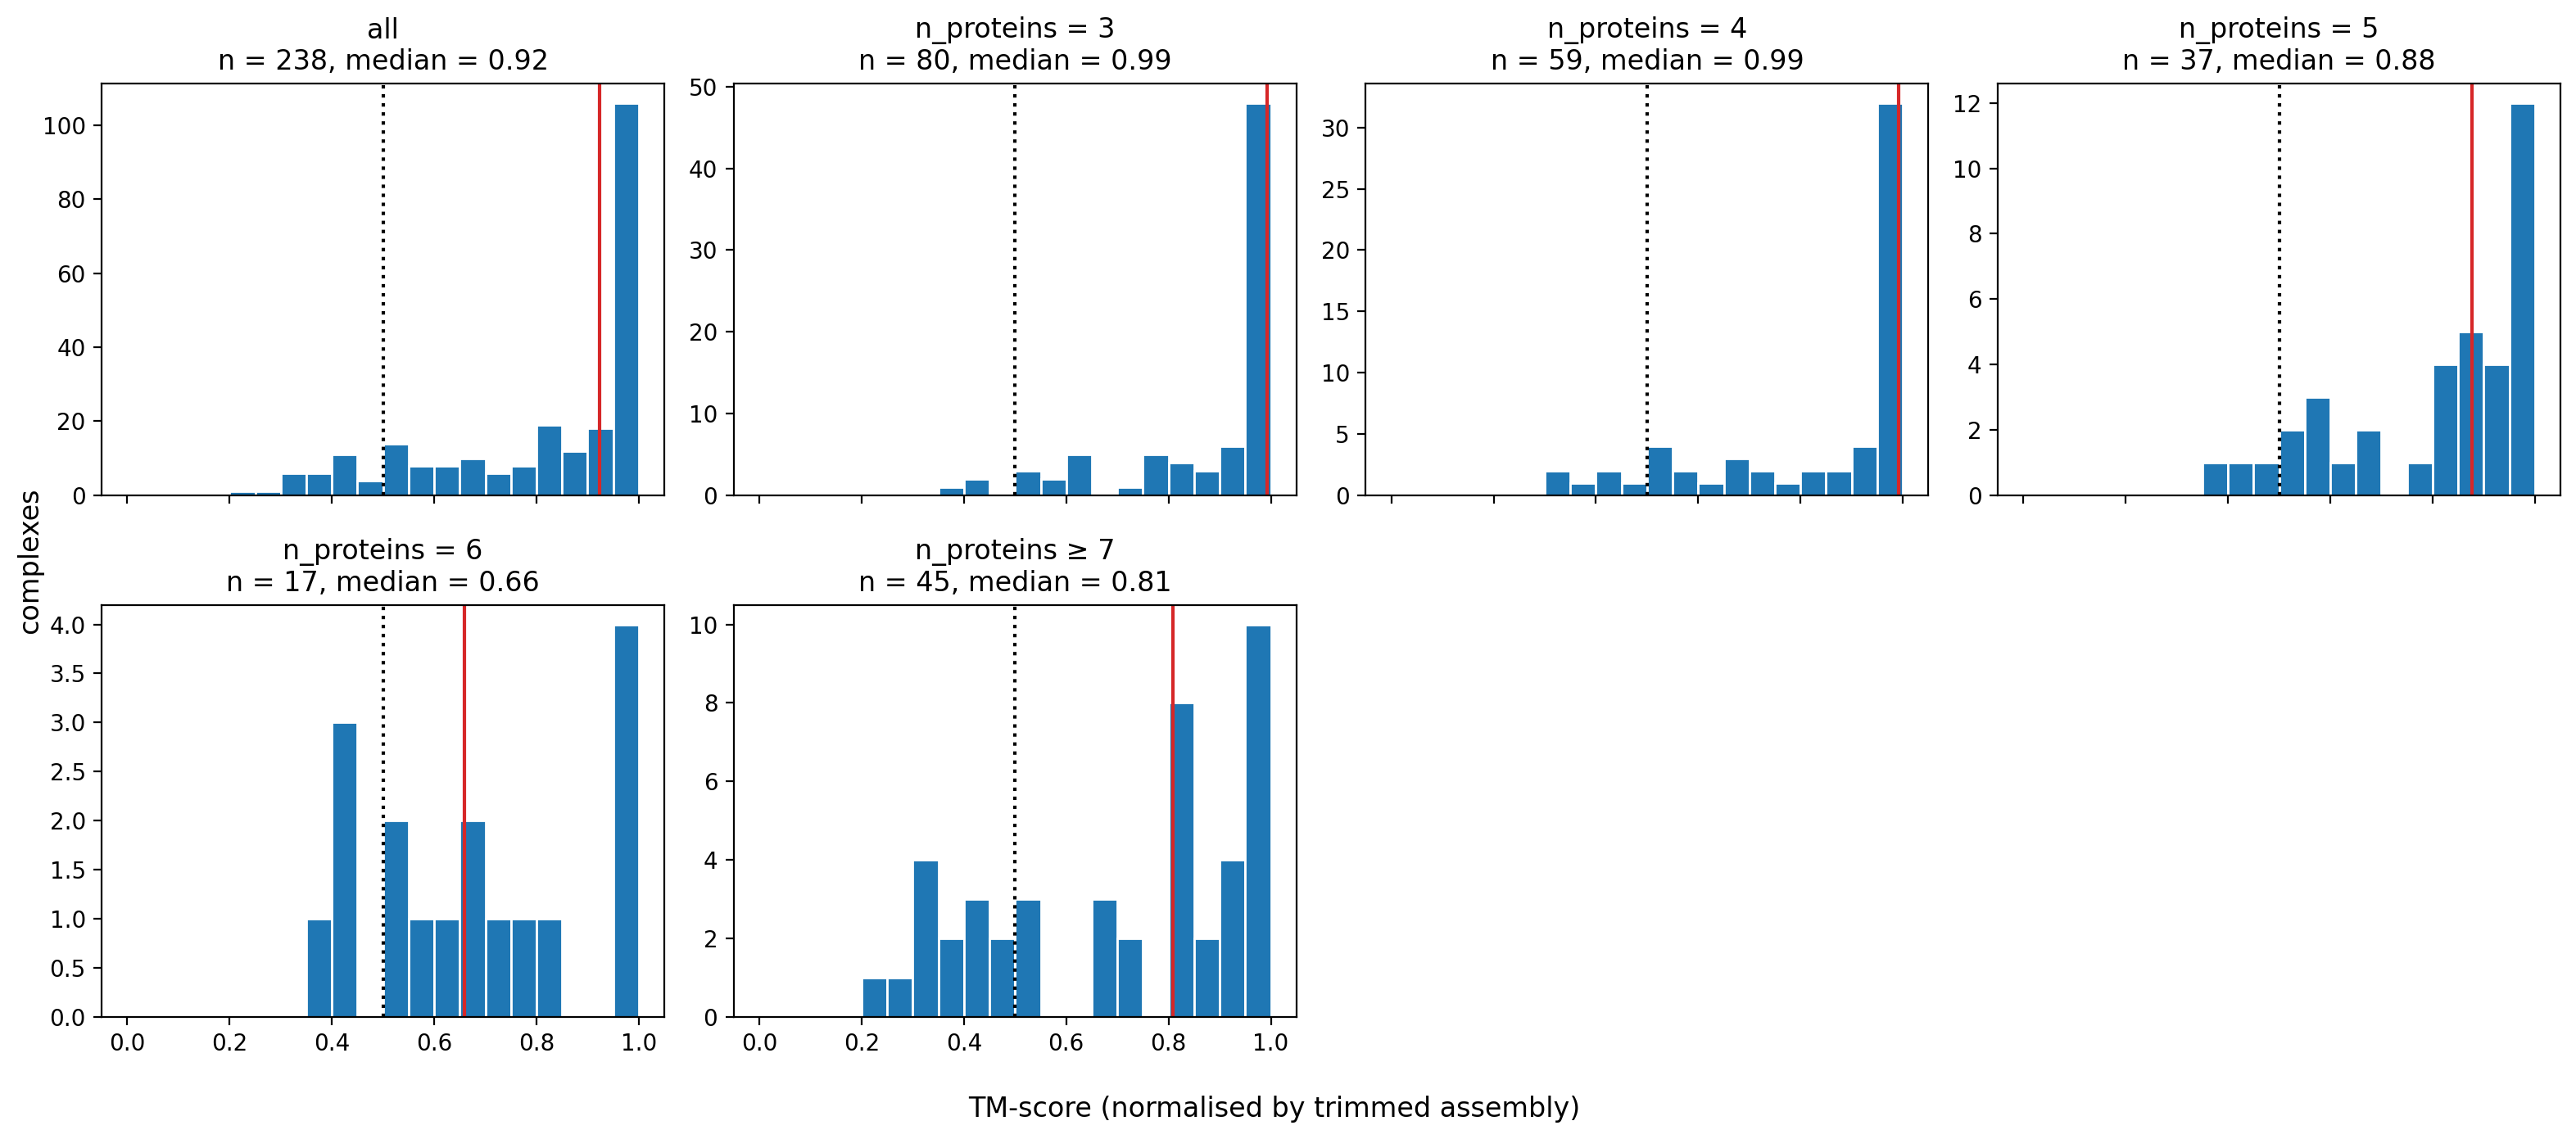

In [9]:

# take prteoins run with pae, highest conf , take the stoi then compare to same sti (highest conf output) for trimmed version

tm_Pae_vs_trimmed = pl.read_csv(PRJ_ROOT/ "scripts/Pipeline/effect_of_trimming/effect_of_trimming_on_cf_assembly.csv")
N_PROTEINS_COMBINED_FROM = 7


complexes_with_tm = tm_Pae_vs_trimmed.filter(pl.col("tm_score_norm_by_trimmed").is_not_null())
print(f"{tm_Pae_vs_trimmed.height - complexes_with_tm.height} complexes without TM-score (not plotted)")

panels = [("all", complexes_with_tm)]
panels += [(f"n_proteins = {n}", complexes_with_tm.filter(pl.col("n_proteins") == n))
           for n in range(3, N_PROTEINS_COMBINED_FROM)]
panels += [(f"n_proteins ≥ {N_PROTEINS_COMBINED_FROM}", complexes_with_tm.filter(pl.col("n_proteins") >= N_PROTEINS_COMBINED_FROM))]
assert sum(panel.height for _, panel in panels[1:]) == complexes_with_tm.height, "groups don't cover all complexes"

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for ax, (label, panel_complexes) in zip(axes.flat, panels):
    tm_scores = panel_complexes["tm_score_norm_by_trimmed"].to_numpy()
    ax.hist(tm_scores, bins=np.arange(0, 1.0001, 0.05), edgecolor="white")
    ax.axvline(0.5, color="black", linestyle=":")
    ax.axvline(np.median(tm_scores), color="tab:red")
    ax.set_title(f"{label}\nn = {len(tm_scores)}, median = {np.median(tm_scores):.2f}")
for ax in list(axes.flat)[len(panels):]:
    ax.set_visible(False)
fig.supxlabel("TM-score (normalised by trimmed assembly)")
fig.supylabel("complexes")
fig.tight_layout()
plt.show()